# Cross-Condition Analysis

In [1]:
import sys
!{sys.executable} -m pip install --quiet decoupler liana requests ipywidgets

In [2]:
from pathlib import Path
import os
import requests
import gc

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import partipy as pt
import decoupler as dc

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## ParTIpy Analysis of on non-classical Monocytes from Lupus Data - Introduction

Cells of the same type often exhibit a continuum of gene expression states, reflecting their functional diversity and adaptability. The Pareto task optimality theory provides a framework to interpret this variability by organizing cells within a low-dimensional polytope in gene expression space. The vertices of this polytope represent specialized "archetypes"—cells optimized for specific tasks performed by the cell type.

Given this theoretical foundation, archetypal analysis is most meaningful when applied to a single cell type. In this vignette, we focus specifically on **non-classical monocytes** to explore their gene expression patterns and uncover the underlying task specialization from their transcriptional profiles. As algorithm for the archetypal analysis we will use PCHA with random initialization.

## Load Data


In [3]:
data_dir = Path(".") / "data"
data_dir.mkdir(exist_ok=True)

# File URL to download
# 
url = "https://datasets.cellxgene.cziscience.com/4532eea4-24b7-461a-93f5-fe437ee96f0a.h5ad"
filename = data_dir / os.path.basename(url)

# Download file if it does not already exist
if not filename.exists():
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    with open(filename, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    
    print(f"Downloaded: {filename}")
else:
    print(f"File already exists, skipping: {filename}")

File already exists, skipping: data/4532eea4-24b7-461a-93f5-fe437ee96f0a.h5ad


In [4]:
adata = sc.read_h5ad(data_dir / "4532eea4-24b7-461a-93f5-fe437ee96f0a.h5ad")
adata.obs["Status"] = adata.obs["disease_state"].map({
    "managed": "Managed",
    "na": "Healthy",
    "flare": "Flare",
    "treated": "Treated"
})
adata = adata[adata.obs["author_cell_type"]=="ncM", :].copy() # only consider non-classical monocytes
adata = adata[adata.obs["Status"] != "Treated", :].copy() # remove samples with "treated" status
# remove columns we don"t need
adata.obs.drop(columns=["mapped_reference_annotation", "cell_type_ontology_term_id", "is_primary_data", 
                        "cell_state", "tissue_ontology_term_id", "development_stage_ontology_term_id", 
                        "tissue", "organism", "tissue_type", "suspension_type", "organism_ontology_term_id",
                        "assay_ontology_term_id", "suspension_enriched_cell_types", "suspension_uuid",
                        "self_reported_ethnicity_ontology_term_id", "disease_ontology_term_id",
                        "sex_ontology_term_id"], 
                        inplace=True)
# create new index
adata.obs.index = [s.split("-")[0] + "-" + str(len(s.split("-"))) + "-" + str(donor_id) 
                   for s, donor_id in zip(adata.obs.index, adata.obs["donor_id"].to_list())]
# remove obsm we don't need
del adata.obsm["X_pca"], adata.obsm["X_umap"], adata.uns
gc.collect()

# use the raw counts
adata.X = adata.raw.X

# use gene symbols instead of ensembl IDs
assert len(adata.var["feature_name"]) == len(adata.var["feature_name"].unique())
adata.var = adata.var.set_index("feature_name")

adata

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'ENSG00000238009.6', 'ENSG00000239945.1']

    Inferred to be: categorical



AnnData object with n_obs × n_vars = 47819 × 30867
    obs: 'library_uuid', 'author_cell_type', 'sample_uuid', 'disease_state', 'donor_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'cell_type', 'assay', 'disease', 'sex', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'Status'
    var: 'feature_is_filtered', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'

- Check the number of cells we have per condition

In [5]:
adata.obs.value_counts("Status")

Status
Managed    31268
Healthy    15091
Flare       1460
Name: count, dtype: int64

## Quality Control

We follow the Scanpy [tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html) to perform quality control on our dataset
We first compute the proportion of counts originating from mitochondrial, ribosomal, and hemoglobin genes:

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [7]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

We can now examine key quality control metrics, including:
- The number of genes expressed per cell
- The total counts per cell
- The percentage of counts originating from mitochondrial genes

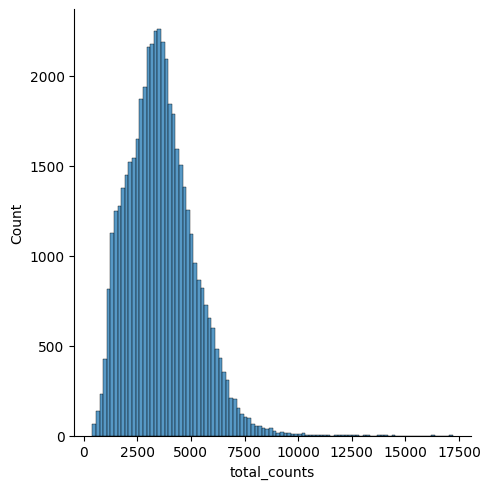

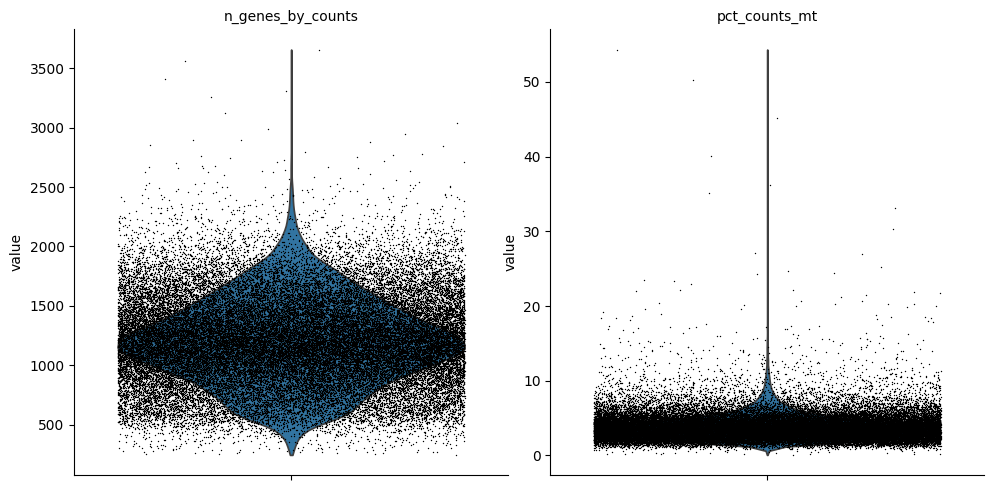

In [8]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

To remove low-quality data, we filter out cells with fewer than 100 detected genes and genes that are present in fewer than 3 cells. This ensures that only high-quality cells and genes are retained for downstream analysis.

In [9]:
print(f"Number of cells before filtering: {adata.n_obs} \nNumber of genes before filtering: {adata.n_vars}")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Number of cells after filtering of low quality cells: {adata.n_obs} \nNumber of genes after filtering of low quality genes: {adata.n_vars}")

Number of cells before filtering: 47819 
Number of genes before filtering: 30867
Number of cells after filtering of low quality cells: 47819 
Number of genes after filtering of low quality genes: 18496


## Normalization and feature selection

To ensure comparability across cells, we normalize the data to the median total counts per cell and apply a logarithmic transformation:

In [10]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

ANext, we identify highly variable genes, which are key for downstream analysis. We also visualize them to assess their distribution:

In [11]:
sc.pp.highly_variable_genes(adata)

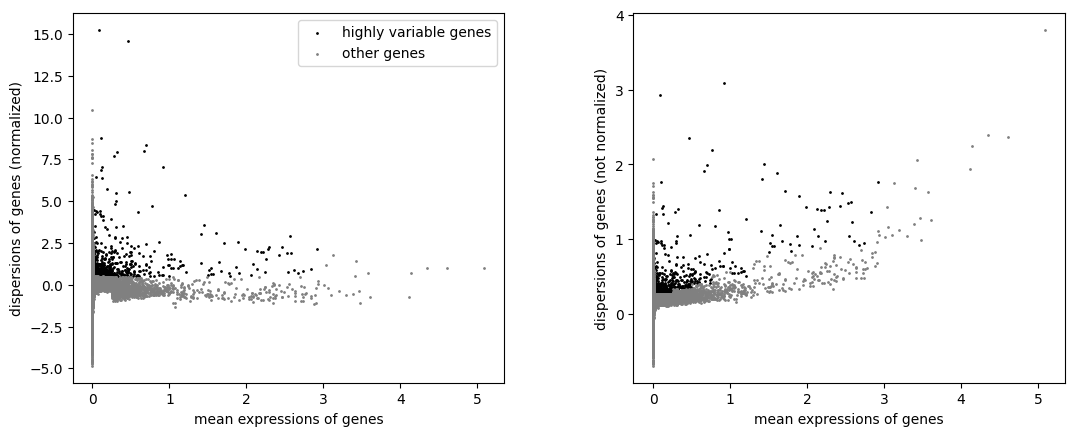

In [12]:
sc.pl.highly_variable_genes(adata)

For downstream enrichment analysis, we standardize the data by scaling gene expression values:

In [13]:
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10)

## Dimension Reduction

We compute Principal Component Analysis (PCA) using only highly variable genes and visualize the results:

In [14]:
adata.obs

,library_uuid,author_cell_type,sample_uuid,disease_state,donor_id,Processing_Cohort,ct_cov,ind_cov,cell_type,assay,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes
GGAGCAAAGTCCAGGA-21-IGTB195,f1568b25-4a87-414f-8329-1a860a3a8aeb,ncM,f0a33a73-192b-4398-b8bc-05eb0c59ae54,na,IGTB195,1.0,NaN,IGTB195_IGTB195,non-classical monocyte,10x 3' v2,...,126.0,4.844187,3.675612,999.0,6.907755,29.142357,0.0,0.0,0.0,1011
AATCCAGCAAATCCGT-27-1772,7c76a618-92ba-41fd-b0a7-306a1c1a6bf2,ncM,a17b2b7f-ab2c-47b0-bb6f-257e8d2fa4c9,flare,1772,3.0,NaN,1772_1772,non-classical monocyte,10x 3' v2,...,117.0,4.770685,2.566352,654.0,6.484635,14.345251,0.0,0.0,0.0,1675
AAGCCGCAGTGAAGTT-79-HC-540,ecd9109f-7197-46df-b3a8-1ac2d9990185,ncM,bc16e1fe-cd25-4a6b-a329-2e2c7121ad8d,na,HC-540,4.0,NaN,HC-540,non-classical monocyte,10x 3' v2,...,126.0,4.844187,3.677758,928.0,6.834109,27.086983,0.0,0.0,0.0,1115
GTCACAAAGTACACCT-51-IGTB498,d49aa545-2b96-409c-85e8-2bf8706475fb,ncM,3672d82d-f24c-4536-b75a-0627889e1426,na,IGTB498,2.0,NaN,IGTB498_IGTB498,non-classical monocyte,10x 3' v2,...,85.0,4.454347,4.714365,523.0,6.261492,29.007212,0.0,0.0,0.0,747
TAAGAGACAGGTGCCT-87-1772,1e3165e4-e0c0-4bf7-b803-7d8271b99fd5,ncM,3178b123-e965-4449-8944-c88b17d0d082,managed,1772,4.0,NaN,1772_1772,non-classical monocyte,10x 3' v2,...,104.0,4.653960,3.262233,792.0,6.675823,24.843163,0.0,0.0,0.0,1039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTACGGTAATCACC-97-1667,10cec51f-a79f-4907-8745-b45df64f6946,ncM,ccccc606-2c86-4d7a-bb4a-8354017807a6,managed,1667,4.0,NaN,1667_1667,non-classical monocyte,10x 3' v2,...,41.0,3.737670,2.726064,303.0,5.717028,20.146276,0.0,0.0,0.0,643
CAGGTGCAGGGAAACA-55-1110,3044f2b9-48b5-45ec-ac14-107f0d7372f0,ncM,5e0ed28c-a75a-4ecd-a0c7-49e71264690b,managed,1110,2.0,NaN,1110_1110,non-classical monocyte,10x 3' v2,...,151.0,5.023880,2.973026,1240.0,7.123673,24.414255,0.0,0.0,0.0,1492
CACACCTAGGCGATAC-56-1056,b795713b-ff23-4494-b6a3-1438b2baee3e,ncM,9198675e-be82-472f-b352-a98629c9876a,managed,1056,2.0,NaN,1056_1056,non-classical monocyte,10x 3' v2,...,143.0,4.969813,2.003362,1612.0,7.385851,22.583357,0.0,0.0,0.0,1975
ATAAGAGAGATCGATA-92-HC-578,16552c24-ef48-4e1f-aff5-319a1f739299,ncM,37d3daeb-c0f5-414a-8b98-0517e7464535,na,HC-578,4.0,NaN,HC-578,non-classical monocyte,10x 3' v2,...,52.0,3.970292,3.542234,394.0,5.978886,26.839239,0.0,0.0,0.0,572


In [15]:
adata.obs.value_counts("Status")

Status
Managed    31268
Healthy    15091
Flare       1460
Name: count, dtype: int64

In [16]:
sc.pp.pca(adata, mask_var="highly_variable")

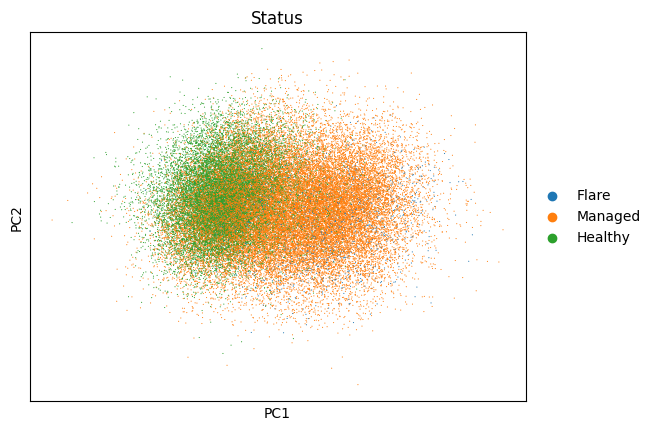

In [17]:
sc.pl.pca_scatter(adata, color="Status")

To determine the optimal number of principal components (PCs) to retain, we inspect their contribution to the total variance:

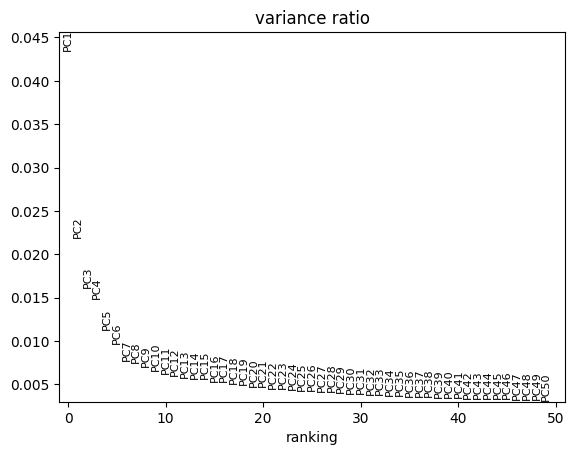

In [18]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

Based on this, we select 7 PCs, as the variance explained plateaus beyond this point.

In [19]:
n_pcs = 7

For ease of use in downstream analysis, we store the number of dimensions in adata.uns["n_pcs"] with the following function:

In [20]:
pt.set_dimension_aa(adata=adata, n_pcs=n_pcs)

## Number of Archetypes

Next, we need to determine the optimal number of archetypes in our data—essentially, the number of vertices in the polyhedron.

We first assess how much variance is explained for different numbers of archetypes.

The function var_explained_aa() takes the reduced PCA data and calculates the explained variance for a range of archetypes (min_a to max_a). Additionally, it computes:

- The variance explained by each archetype.
- The additional variance explained by each successive archetype.
- The distance from the projected point to the line of the elbow plot.

In [21]:
pt.var_explained_aa(adata=adata, min_a=2, max_a=10)

The results are stored in:

In [22]:
adata.uns["AA_var"]

,k,IC,varexpl,varexpl_ontop,dist_to_projected
0,2,5.980471,0.344612,0.344612,0.000000
1,3,5.184308,0.510812,0.166200,0.095379
2,4,5.227411,0.615966,0.105154,0.129864
3,5,5.178468,0.713352,0.097386,0.156599
4,6,5.243269,0.779734,0.066381,0.152407
5,7,5.674095,0.822363,0.042629,0.124522
6,8,5.594956,0.869273,0.046910,0.100907
7,9,6.217166,0.884659,0.015386,0.045846
8,10,6.293580,0.909282,0.024623,0.000000


We visualize the explained variance for different models:

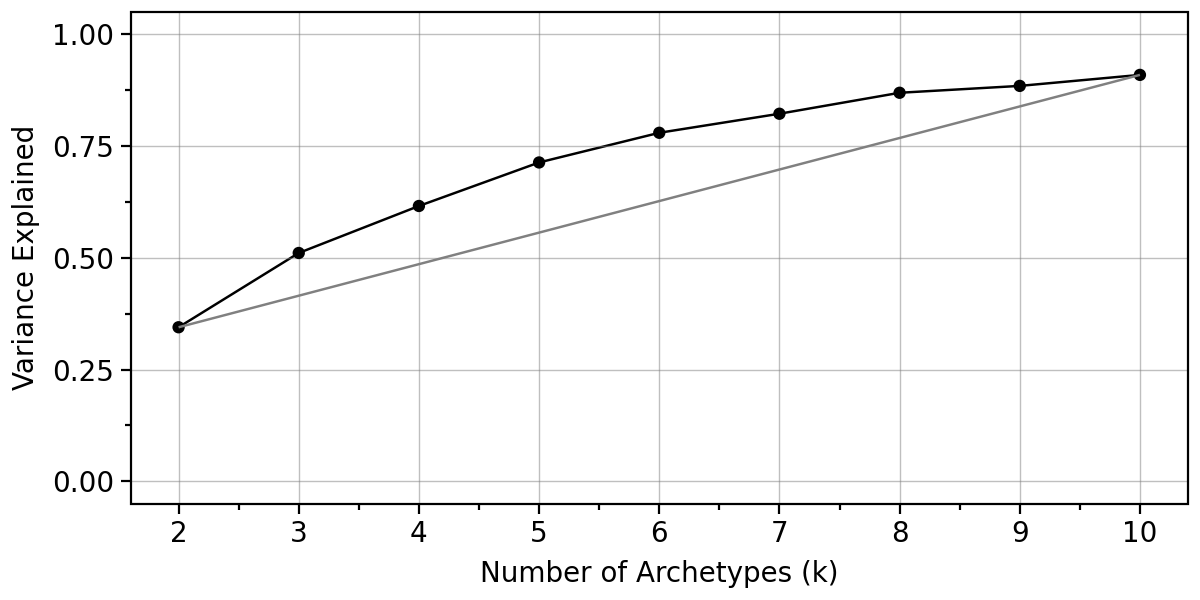

In [23]:
pt.plot_var_explained(adata)

In this plot, the grey line connects the first and last variance explained (EV) values, helping to identify the "elbow" of the black curve.

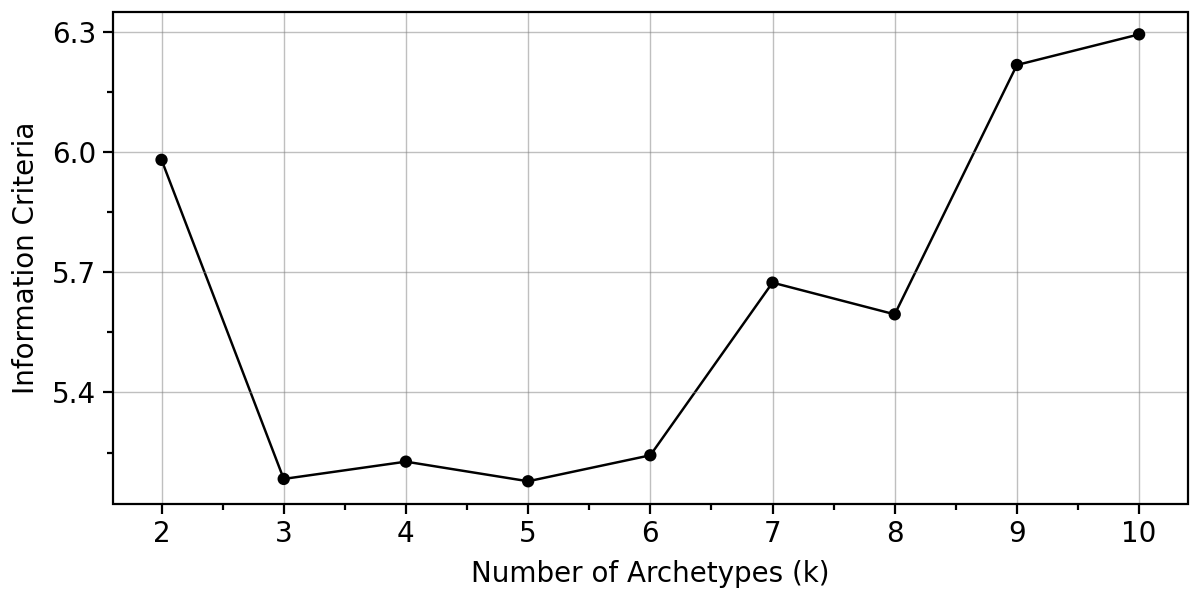

In [24]:
pt.plot_IC(adata)

This analysis suggests that the best choice is 4-6 archetypes. We decide to use 4 archetypes, as later analyses show that the 5th archetype introduces no new tasks.

In [25]:
n_archetypes = 4

To validate the archetype stability, we apply bootstrapping. We sample the data five times (for efficiency) and run Archetypal Analysis (AA) on each sample. 

In [26]:
pt.bootstrap_aa(adata=adata, n_bootstrap=20, n_archetypes=n_archetypes)

The positions of the archetypes and the mean variance across all bootstrapped samples are stored in:

In [27]:
adata.uns["AA_bootstrap"]

,pc_0,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,archetype,iter,reference,mean_variance,variance_per_archetype
0,4.091356,1.734030,3.549531,-1.533424,0.397991,0.181333,0.013504,0,1,False,1.896297,3.196712
1,-4.972725,-3.438379,0.669235,-0.283837,0.172592,-0.225229,0.221447,1,1,False,1.896297,0.401130
2,5.657241,-2.323601,-2.859990,1.081608,-0.113433,-0.223672,-0.130132,2,1,False,1.896297,1.029285
3,-2.003138,4.140690,-1.351022,0.648190,-0.385386,0.107479,-0.172858,3,1,False,1.896297,2.958061
0,-2.973515,4.043552,3.574710,0.032013,0.012289,-0.216187,0.467469,0,2,False,1.896297,3.196712
...,...,...,...,...,...,...,...,...,...,...,...,...
3,-1.728157,3.787378,-2.798076,0.723159,-0.571892,0.114653,-0.117109,3,20,False,1.896297,2.958061
0,4.023981,1.835257,3.543122,-1.540318,0.510409,0.178903,0.056492,0,0,True,1.896297,3.196712
1,-4.866747,-3.526805,0.617452,-0.375910,0.334869,-0.164731,0.209311,1,0,True,1.896297,0.401130
2,5.708945,-2.312775,-2.763483,1.178099,-0.157756,-0.188906,-0.128136,2,0,True,1.896297,1.029285


We visualize the bootstrapping results:

In [28]:
pt.plot_bootstrap_3D(adata)

The results show that the archetypes are mostly stable, supporting our selection. 

## Archetype Analysis and visualization

Now that we've determined the number of archetypes, we can compute the four archetypes and save them to our AnnData object:

In [29]:
pt.compute_archetypes(adata, n_archetypes, verbose=True, archetypes_only=False, optim="frank_wolfe")

RSS: 221463.296875 | rel_delta_RSS: -0.000073
Algorithm converged after 39 iterations.


The results including the archetypes are stored here

In [30]:
adata.uns["archetypal_analysis"]["Z"]

array([[ 2.850765  ,  2.596009  ,  3.586489  , -1.4500784 ,  0.60676336,
        -0.09309787,  0.13528435],
       [-4.8230715 , -3.0351825 ,  0.6907446 , -0.21893005, -0.11787225,
        -0.0554888 ,  0.02207322],
       [ 5.9561343 , -2.6091247 , -2.0603034 ,  0.7593351 , -0.15418169,
        -0.12290286, -0.10193071],
       [-1.7044237 ,  3.9574187 , -2.0729792 ,  0.76451707, -0.33145893,
         0.080245  , -0.08888795]], dtype=float32)

We can manually check for the convergence here

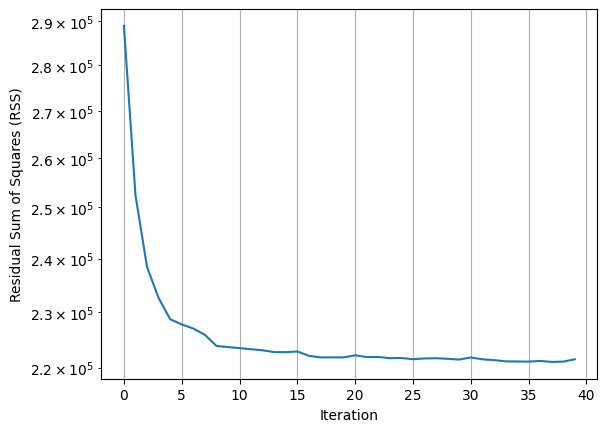

In [31]:
plt.plot(adata.uns["archetypal_analysis"]["RSS"])
plt.grid()
plt.xlabel("Iteration", y="Residual Sum of Squares (RSS)")
plt.ylabel("Residual Sum of Squares (RSS)")
plt.yscale("log")
plt.show()

We can visualize the polytope in both 2D and 3D. We want the colors to represent the disease status.
Alternatively, we can color the plot based on a gene with distinct expression across archetypes. For example, using the gene IFI27.

We visualize the polytope in 2D with the following:

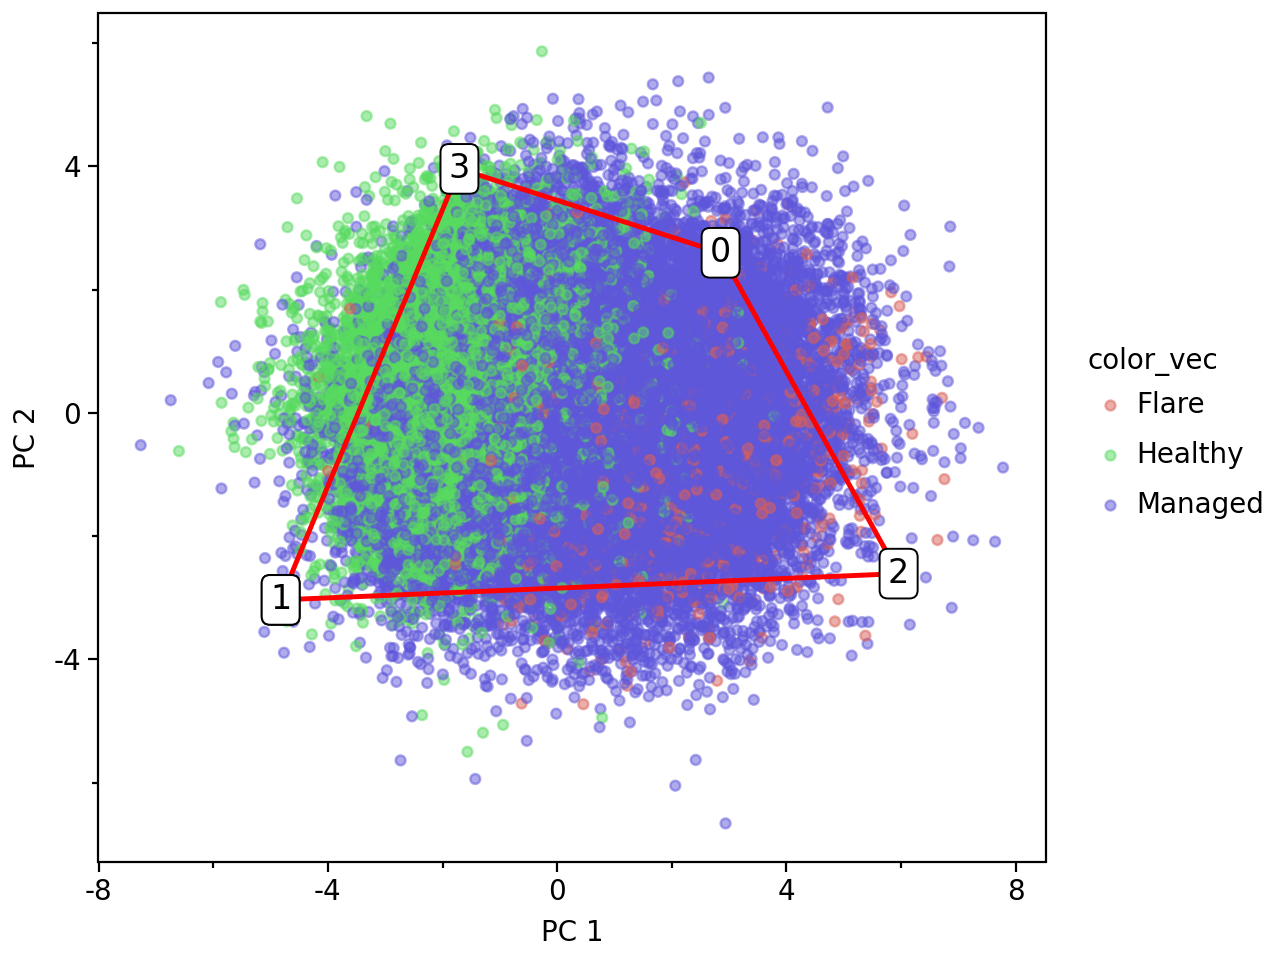

In [32]:
pt.plot_archetypes_2D(adata=adata, color="Status")

For a 3D representation, we can plot the data along with the archetypes in a 3D space. You may choose to subset the data if necessary:

In [33]:
pt.plot_archetypes_3D(adata=adata, color="Status")

## Identify representatives

To assign tasks to the archetypes, we need to identify cells that are representative of each archetype. To do this, we calculate a weighted pseudobulk for each archetype.

First, we calculate the weights for each cell based on its distance from the archetypes. The length scale of the RBF kernel is automatically set as half the median distance from the data centroid to the archetypes. However, this can also be manually adjusted if needed:

In [34]:
pt.compute_archetype_weights(X=adata, mode="automatic")

Applied length scale is 2.8109821945412223.


We can visualize the cell weights for each archetype to assess their distribution:

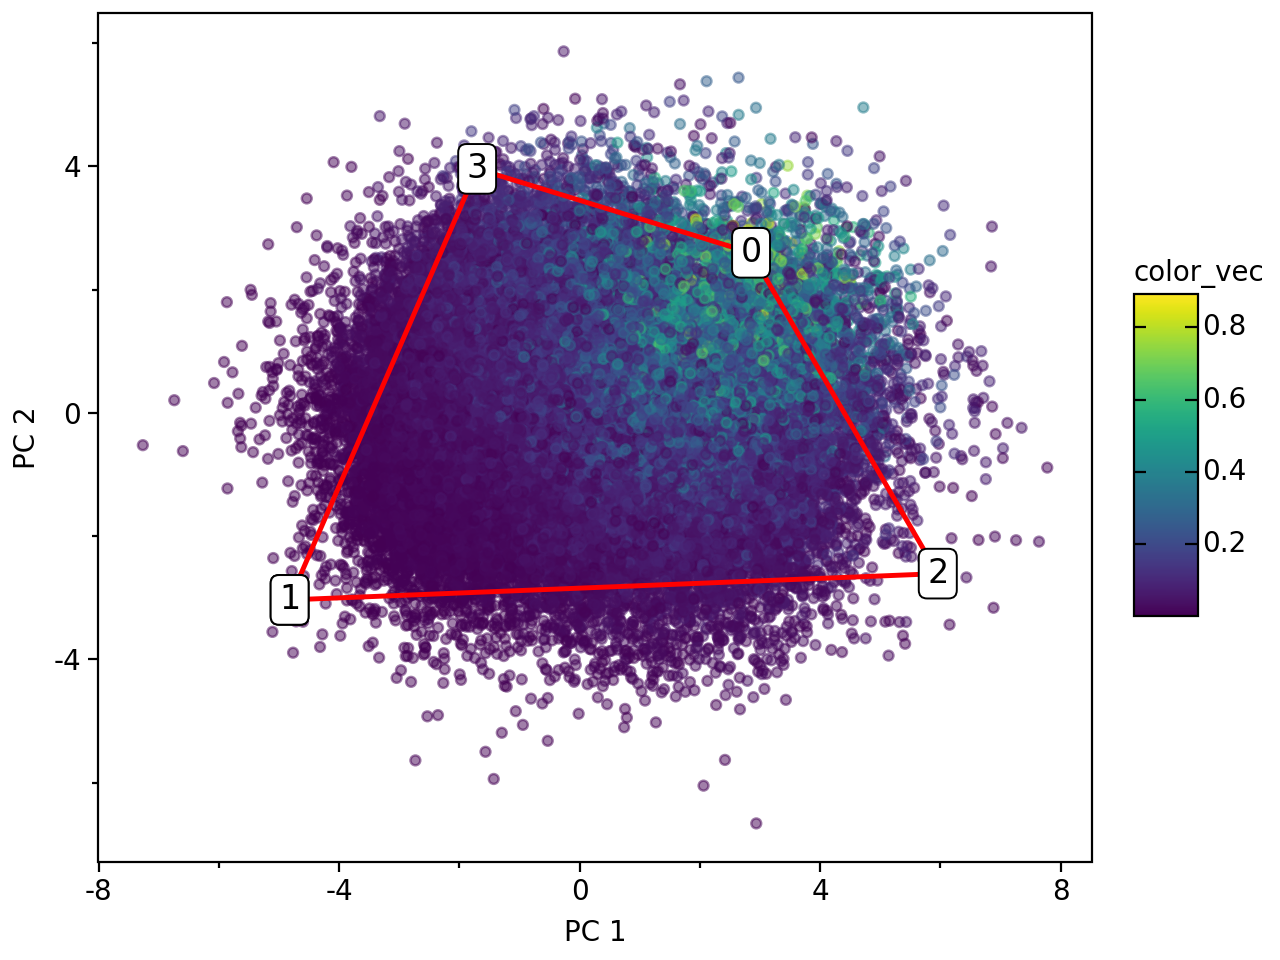

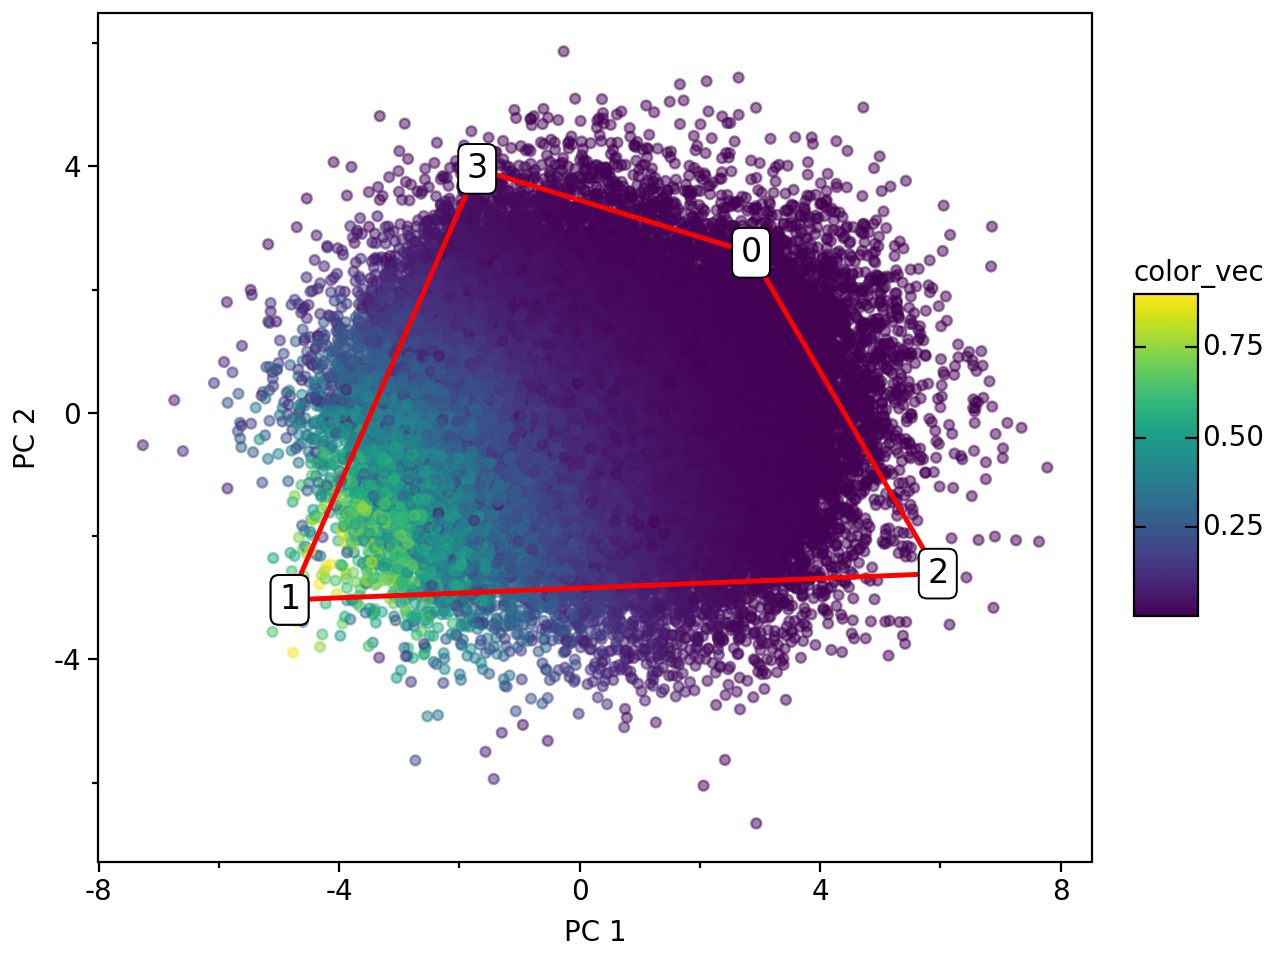

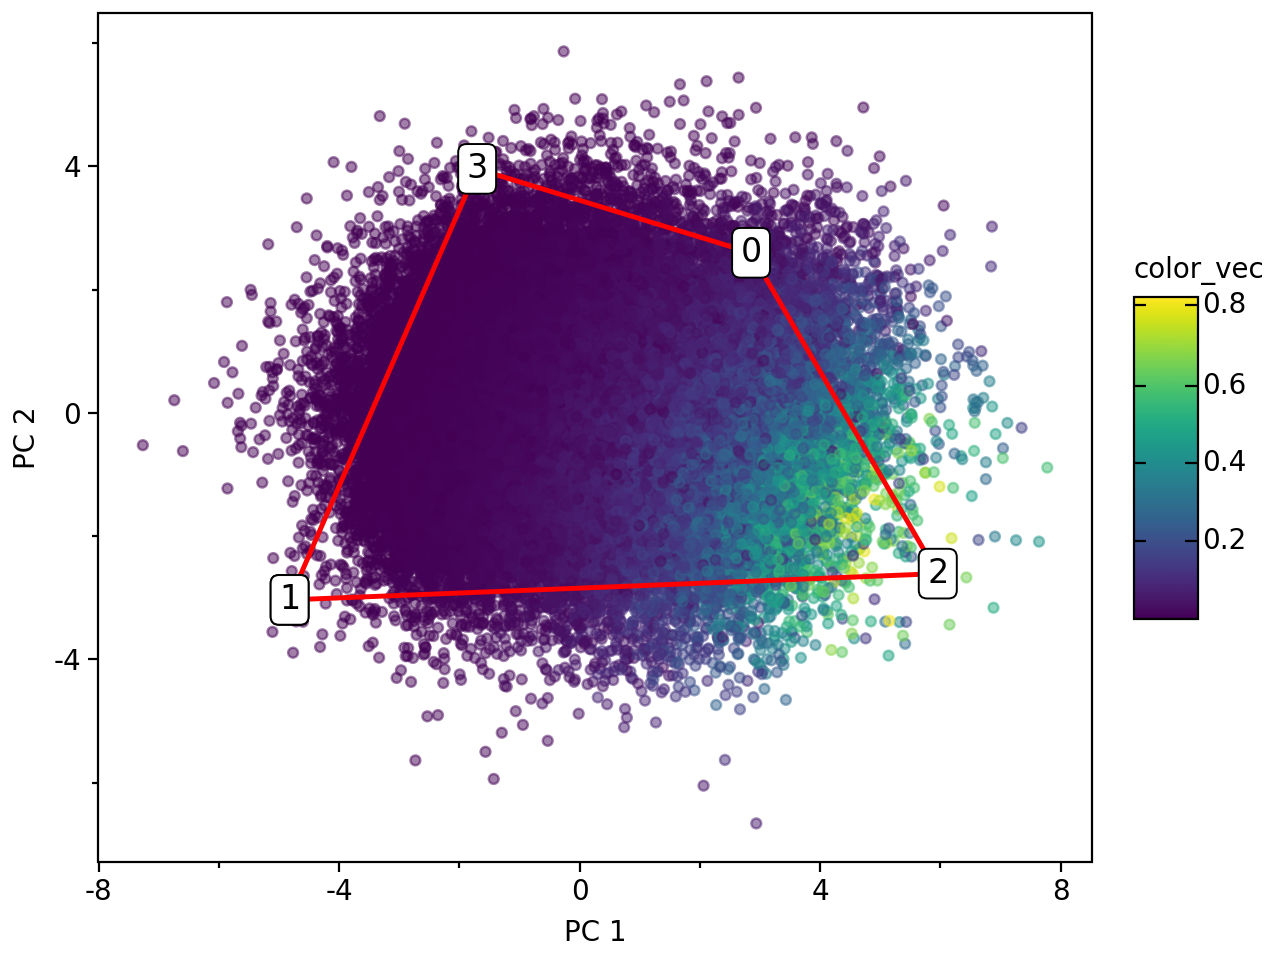

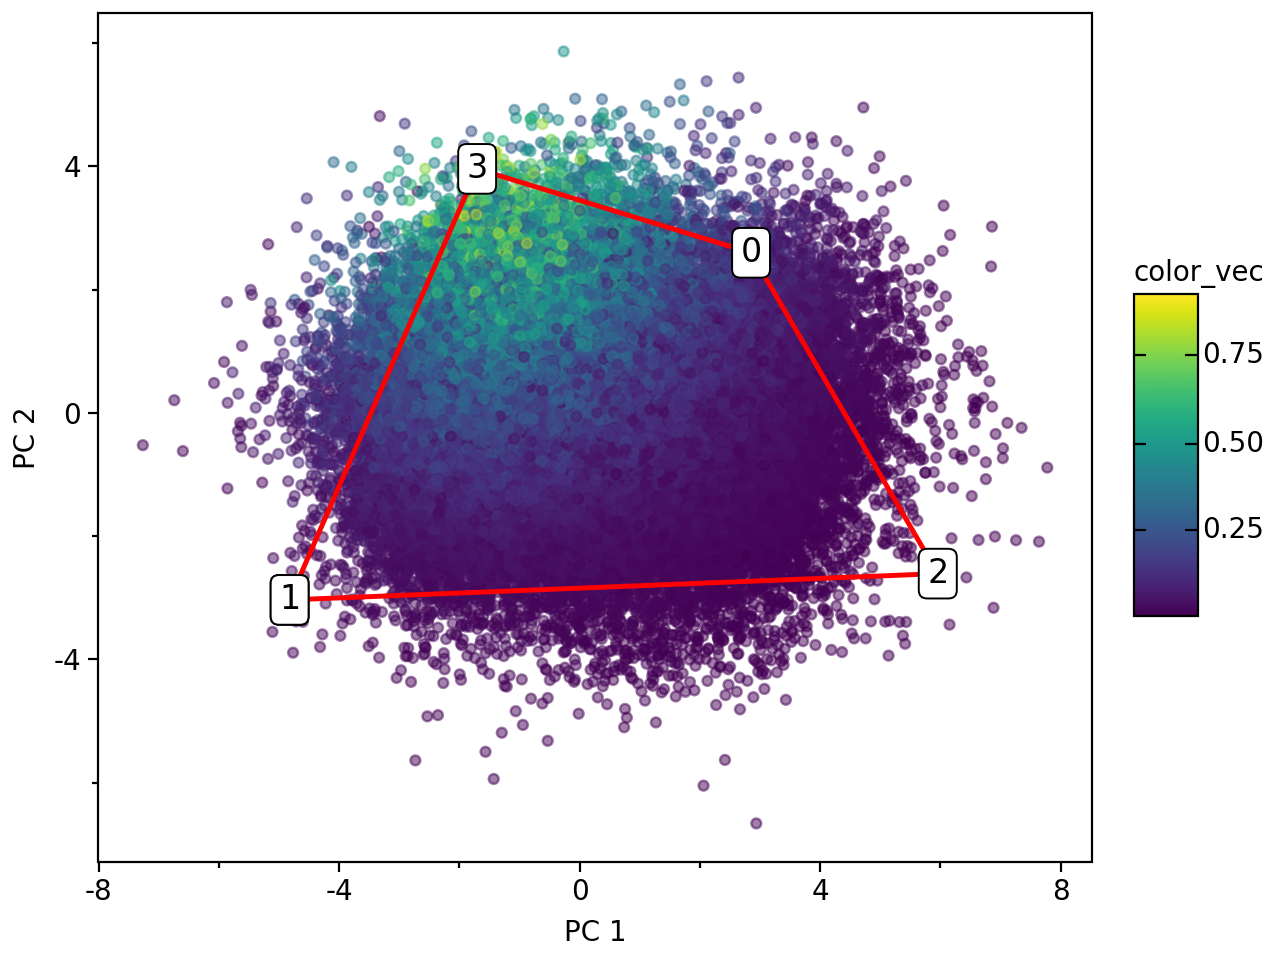

In [35]:
for i in range(0,4):
    plot = pt.plot_2D(adata.obsm["X_pca"], Z = adata.uns["archetypal_analysis"]["Z"], color_vec=adata.obsm["cell_weights"].T[i])
    plot.show()

## Enrichment Metadata

With the weights we can now calculate enrichment of interest. Since we have different cell status associated with healthy and disease, we want first to check the enrichment by the "disease_state and find our archetypes of interest.

meta_enrichment() calcualtes the enrichment of any specified metadata stored in obs. 

In [36]:
status_enrichment = pt.compute_meta_enrichment(adata=adata, meta_col="Status")
status_enrichment

,Flare,Managed,Healthy
0,0.323350,0.462927,0.213723
1,0.173549,0.283803,0.542648
2,0.584252,0.349158,0.066589
3,0.204273,0.280184,0.515544


We find ncM with the "Flare" status enriched at archetype 2 and not associated with archetype 0. We can observe such distribution in the PCA space when plotting only the ncM with "Flare" status: 

In [37]:
pt.plot_archetypes_3D(adata, color="Status")

We can also visualize the results like this:

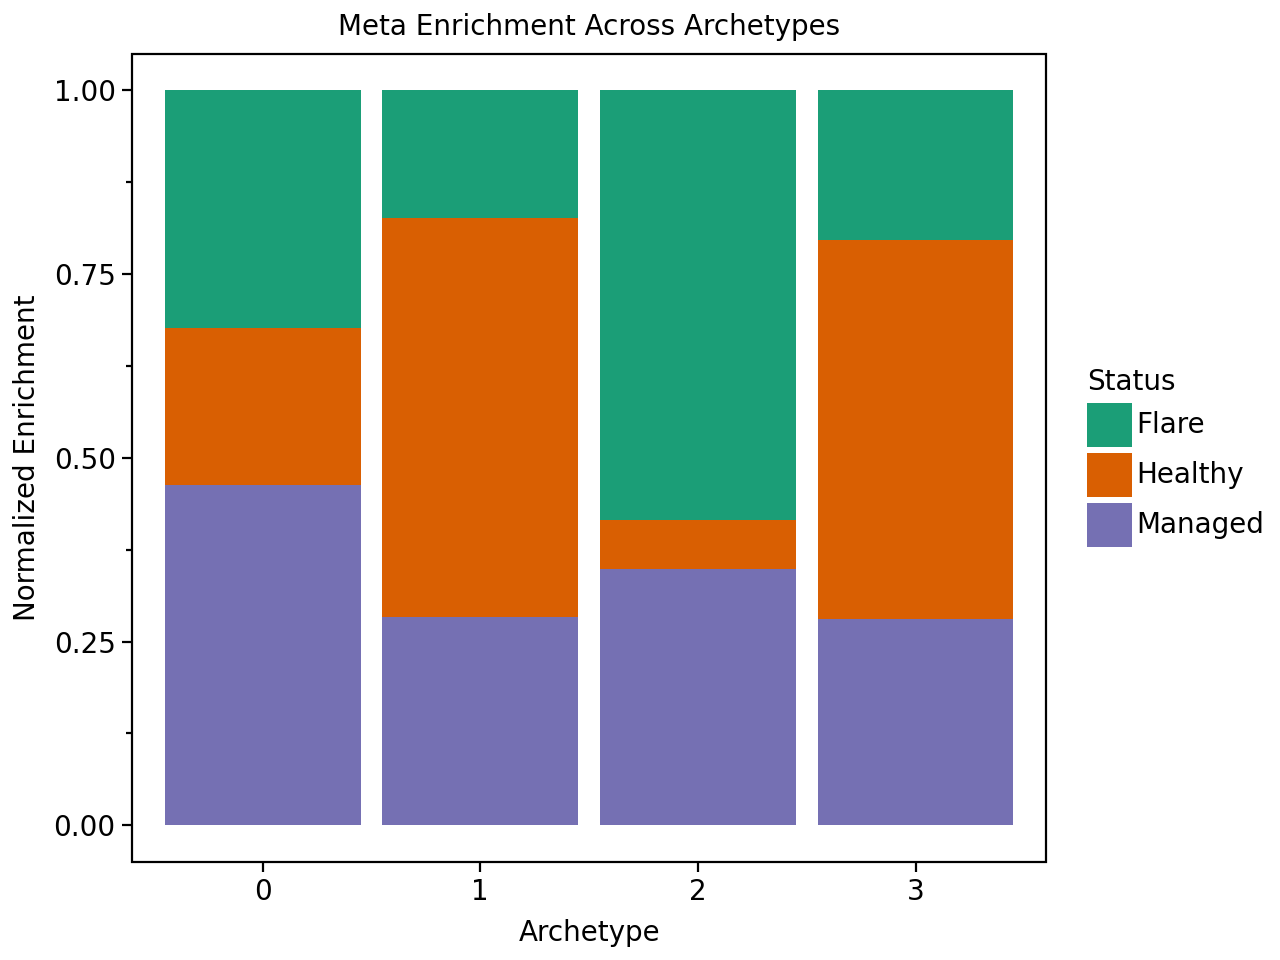

In [38]:
pt.barplot_meta_enrichment(status_enrichment, meta="Status")

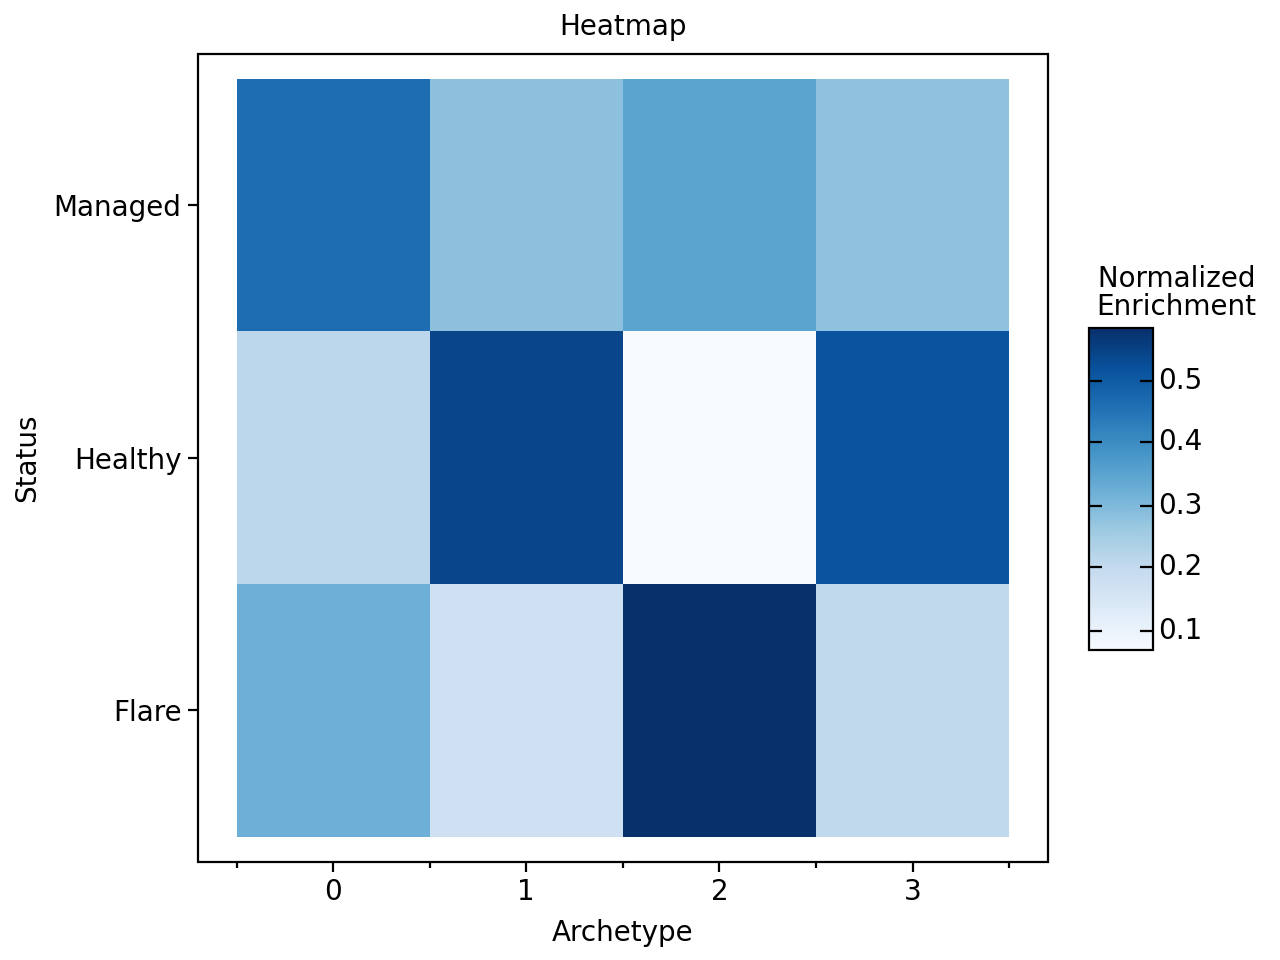

In [39]:
pt.heatmap_meta_enrichment(status_enrichment, meta="Status")

## Functional Enrichment MSigDB

Next, we compute a pseudobulk using the z-scaled gene expression data to observe differences in gene expression across the archetypes:

In [40]:
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")
archetype_expression.iloc[:, 20:25]

,TNFRSF4,SDF4,B3GALT6,C1QTNF12,ENSG00000260179.1
0,-0.012904,0.041988,-0.008542,-0.020430,-0.017932
1,-0.013423,-0.018682,-0.008606,-0.023915,-0.022003
2,-0.024856,0.010489,-0.005783,-0.024298,-0.022283
3,-0.011545,-0.000887,-0.003085,-0.016440,-0.018278


For functional enrichment, we use Decoupler with Gene Ontology (GO) biological processes. While other collections can be used, it’s recommended to choose those with less broad categories to avoid non-significant results.

We begin by loading the MSigDB resource and filtering for the GO biological processes collection:

In [41]:
msigdb_raw = dc.get_resource("MSigDB")
msigdb = msigdb_raw[msigdb_raw["collection"]=="go_biological_process"]
msigdb = msigdb[~msigdb.duplicated(["geneset", "genesymbol"])]

Next, we run ULM on the pseudobulk data using the filtered MSigDB resource. The results are saved in acts_ulm_est and acts_ulm_est_p:

In [42]:
acts_ulm_est_msigdb, acts_ulm_est_p_msigdb = dc.run_ulm(mat = archetype_expression,
                                                        net = msigdb,
                                                        weight = None,
                                                        source="geneset",
                                                        target="genesymbol")

acts_ulm_est_msigdb

,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,GOBP_2FE_2S_CLUSTER_ASSEMBLY,GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,GOBP_4FE_4S_CLUSTER_ASSEMBLY,GOBP_5S_CLASS_RRNA_TRANSCRIPTION_BY_RNA_POLYMERASE_III,GOBP_5_PHOSPHORIBOSE_1_DIPHOSPHATE_METABOLIC_PROCESS,GOBP_7_METHYLGUANOSINE_CAP_HYPERMETHYLATION,...,GOBP_XENOBIOTIC_TRANSPORT,GOBP_XENOBIOTIC_TRANSPORT_ACROSS_BLOOD_BRAIN_BARRIER,GOBP_XENOPHAGY,GOBP_XMP_METABOLIC_PROCESS,GOBP_XYLULOSE_5_PHOSPHATE_METABOLIC_PROCESS,GOBP_ZINC_ION_IMPORT_ACROSS_PLASMA_MEMBRANE,GOBP_ZINC_ION_IMPORT_INTO_ORGANELLE,GOBP_ZINC_ION_TRANSPORT,GOBP_ZYMOGEN_ACTIVATION,GOBP_ZYMOGEN_INHIBITION
0,-0.065426,0.361172,0.714155,-0.018099,6.998197,5.960048,0.194684,0.457179,0.719514,0.644482,...,-1.433106,-0.713722,3.977708,0.232838,0.375001,0.024641,-0.146844,-0.107377,4.192554,0.893528
1,0.028647,-0.390663,-0.443806,-0.690830,-1.988152,-1.226114,0.240927,0.355455,0.052463,-0.253761,...,-0.332174,0.280620,-2.257449,-0.171397,-0.885517,0.269177,0.368853,0.630269,-3.201582,-0.429436
2,0.264822,1.979750,0.984594,0.747184,-1.811305,-1.242975,1.120389,0.370405,0.587225,3.283632,...,-0.590383,-0.509316,1.347057,-0.220450,1.113352,-0.091891,0.287350,0.350942,3.407085,1.853624
3,0.042133,0.415202,0.519865,-0.114227,2.744202,2.683055,0.282551,0.784878,0.904912,-0.184985,...,-0.668600,-0.089070,0.660557,1.721050,0.504811,0.817643,0.377713,0.749187,-2.950000,-0.451995


To identify the top enriched processes for each archetype, we extract the top n processes and order them in descending order:

In [43]:
top_processes_msigdb = pt.extract_enriched_processes(est=acts_ulm_est_msigdb, 
                                                     pval=acts_ulm_est_p_msigdb, 
                                                     order="desc", 
                                                     n=20, 
                                                     p_threshold=0.05)

We can access them using the keys in the form of "archetype_X". For example, for archetype 2, which is enriched in “Flare,” we observe an enrichment of processes related to the immune response to viruses and the response to interferon.

In [44]:
top_processes_msigdb[2].round(2)

,Process,0,1,2,3,specificity
0,GOBP_NEGATIVE_REGULATION_OF_VIRAL_GENOME_REPLI...,18.440001,-18.650000,25.650000,-19.870001,7.21
1,GOBP_NEGATIVE_REGULATION_OF_VIRAL_PROCESS,21.070000,-20.500000,24.690001,-17.320000,3.62
2,GOBP_DEFENSE_RESPONSE_TO_SYMBIONT,20.900000,-18.549999,23.049999,-13.270000,2.15
3,GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM,26.379999,-22.010000,22.020000,-5.820000,-4.37
4,GOBP_INNATE_IMMUNE_RESPONSE,24.900000,-20.830000,21.910000,-6.680000,-2.99
5,GOBP_RESPONSE_TO_VIRUS,21.770000,-17.870001,21.190001,-10.020000,-0.58
6,GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECI...,29.320000,-22.010000,20.750000,-3.420000,-8.57
7,GOBP_REGULATION_OF_VIRAL_PROCESS,20.879999,-19.580000,20.320000,-10.550000,-0.55
8,GOBP_DEFENSE_RESPONSE,27.690001,-22.459999,20.139999,-4.220000,-7.55
9,GOBP_IMMUNE_RESPONSE,26.500000,-22.600000,19.969999,-2.220000,-6.53


On the other hand, archetype 3 seems to represent the task of upkeeping homeostasis and normal cellular function in the cells.

In [45]:
top_processes_msigdb[3].round(2)

,Process,0,1,2,3,specificity
0,GOBP_CYTOPLASMIC_TRANSLATION,0.77,9.080000,-19.85,49.660000,40.580002
1,GOBP_PEPTIDE_BIOSYNTHETIC_PROCESS,8.32,5.270000,-6.58,28.920000,20.590000
2,GOBP_PEPTIDE_METABOLIC_PROCESS,8.72,4.260000,-5.41,27.750000,19.020000
3,GOBP_AMIDE_BIOSYNTHETIC_PROCESS,7.93,5.310000,-5.79,26.950001,19.030001
4,GOBP_CELLULAR_MACROMOLECULE_BIOSYNTHETIC_PROCESS,7.65,5.220000,-4.65,24.420000,16.770000
5,GOBP_AMIDE_METABOLIC_PROCESS,8.53,3.750000,-3.51,24.299999,15.770000
6,GOBP_ORGANONITROGEN_COMPOUND_BIOSYNTHETIC_PROCESS,7.85,4.130000,-1.66,22.920000,15.070000
7,GOBP_PEPTIDE_ANTIGEN_ASSEMBLY_WITH_MHC_CLASS_I...,13.22,-32.330002,14.18,16.360001,2.180000
8,GOBP_RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,6.04,4.990000,-0.11,15.910000,9.870000
9,GOBP_RIBOSOME_BIOGENESIS,3.87,4.200000,-0.76,14.660000,10.460000


To identify processes specific to a particular archetype, meaning they are in the top enriched processes of one archetype and below a specified threshold (drop_threshold) for all other archetypes, we apply the following function:

In [46]:
specific_processes_msigdb = pt.extract_specific_processes(est=acts_ulm_est_msigdb,
                                                          pval=acts_ulm_est_p_msigdb, 
                                                          n=10,
                                                          p_threshold=0.05)

specific_processes_msigdb[2].round(2)

,Process,0,1,2,3,specificity
0,GOBP_RESPONSE_TO_INTERFERON_BETA,12.080000,-14.35,19.299999,-13.630000,7.22
1,GOBP_NEGATIVE_REGULATION_OF_VIRAL_GENOME_REPLI...,18.440001,-18.65,25.650000,-19.870001,7.21
2,GOBP_MITOCHONDRIAL_TRANSLATION,4.020000,-2.38,8.950000,-0.460000,4.93
3,GOBP_SEQUESTERING_OF_ACTIN_MONOMERS,0.390000,-3.19,5.080000,-4.110000,4.69
4,GOBP_POSITIVE_REGULATION_OF_SEQUESTERING_OF_CA...,0.450000,-2.94,5.130000,-2.650000,4.67
5,GOBP_NEGATIVE_REGULATION_OF_RYANODINE_SENSITIV...,0.700000,-2.95,5.110000,-2.670000,4.41
6,GOBP_REGULATION_OF_IRON_ION_TRANSPORT,1.300000,-3.09,5.660000,-5.220000,4.36
7,GOBP_MITOCHONDRIAL_GENE_EXPRESSION,4.160000,-1.97,8.460000,0.260000,4.30
8,GOBP_REGULATION_OF_PROTEIN_K48_LINKED_UBIQUITI...,0.550000,-3.02,4.670000,0.530000,4.12
9,GOBP_POSITIVE_REGULATION_OF_RECEPTOR_BINDING,2.060000,-3.83,6.120000,-5.800000,4.07


For visualization we can plot the obtained results:

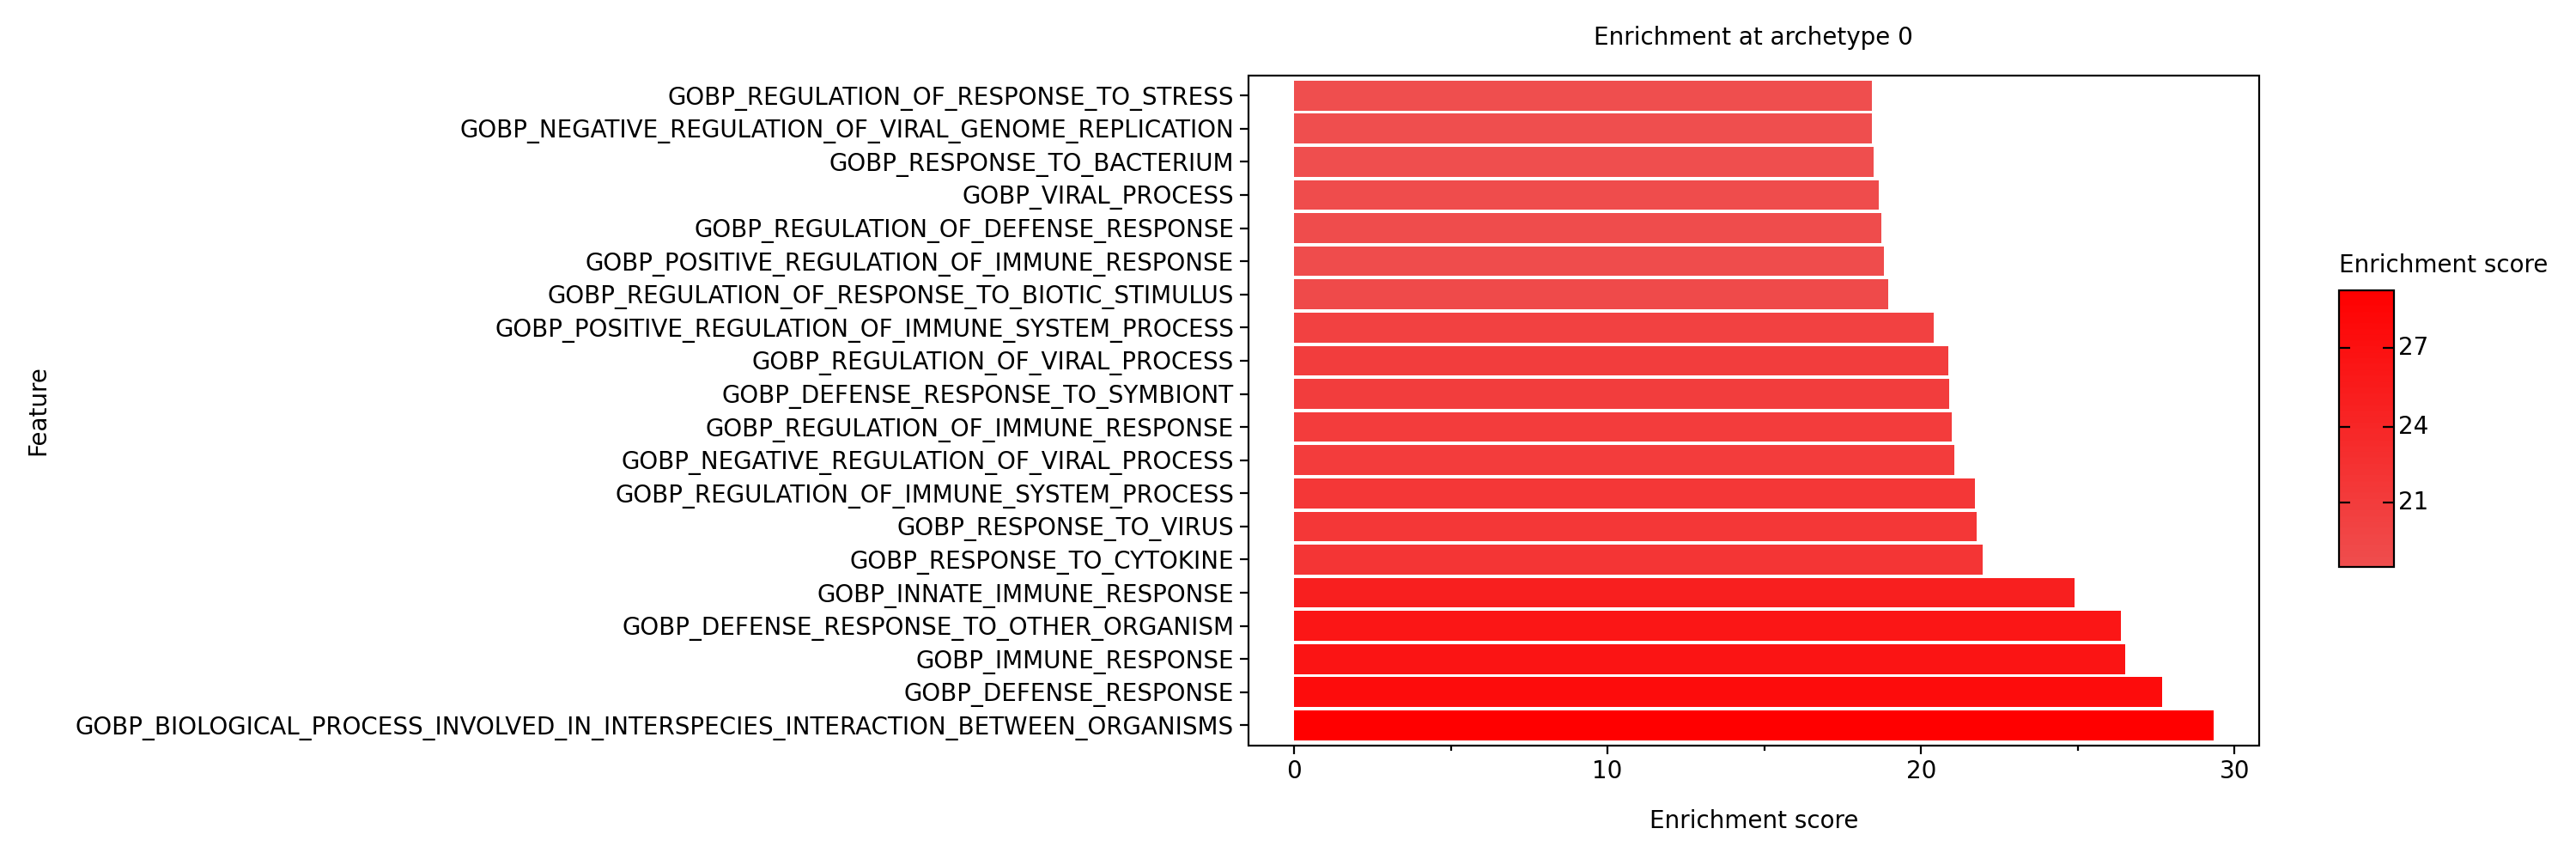

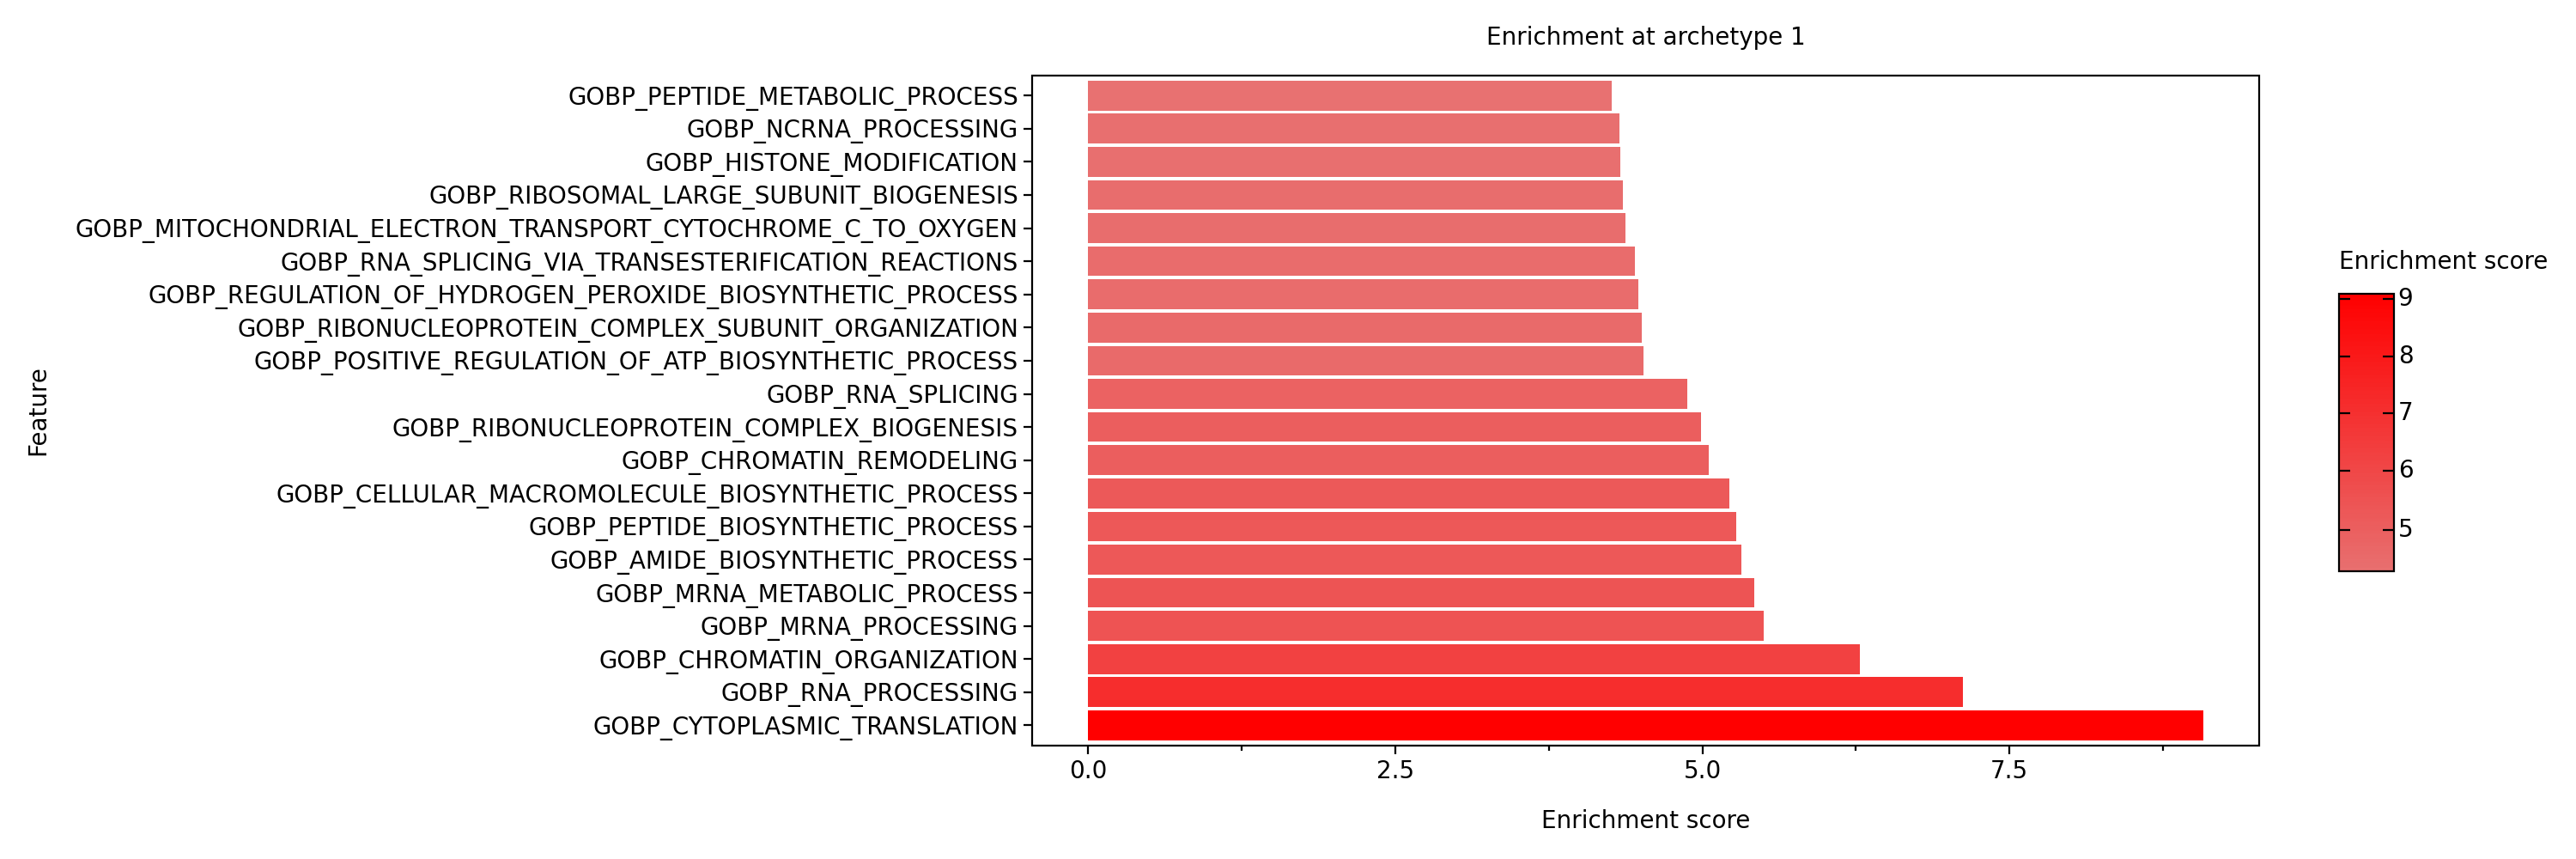

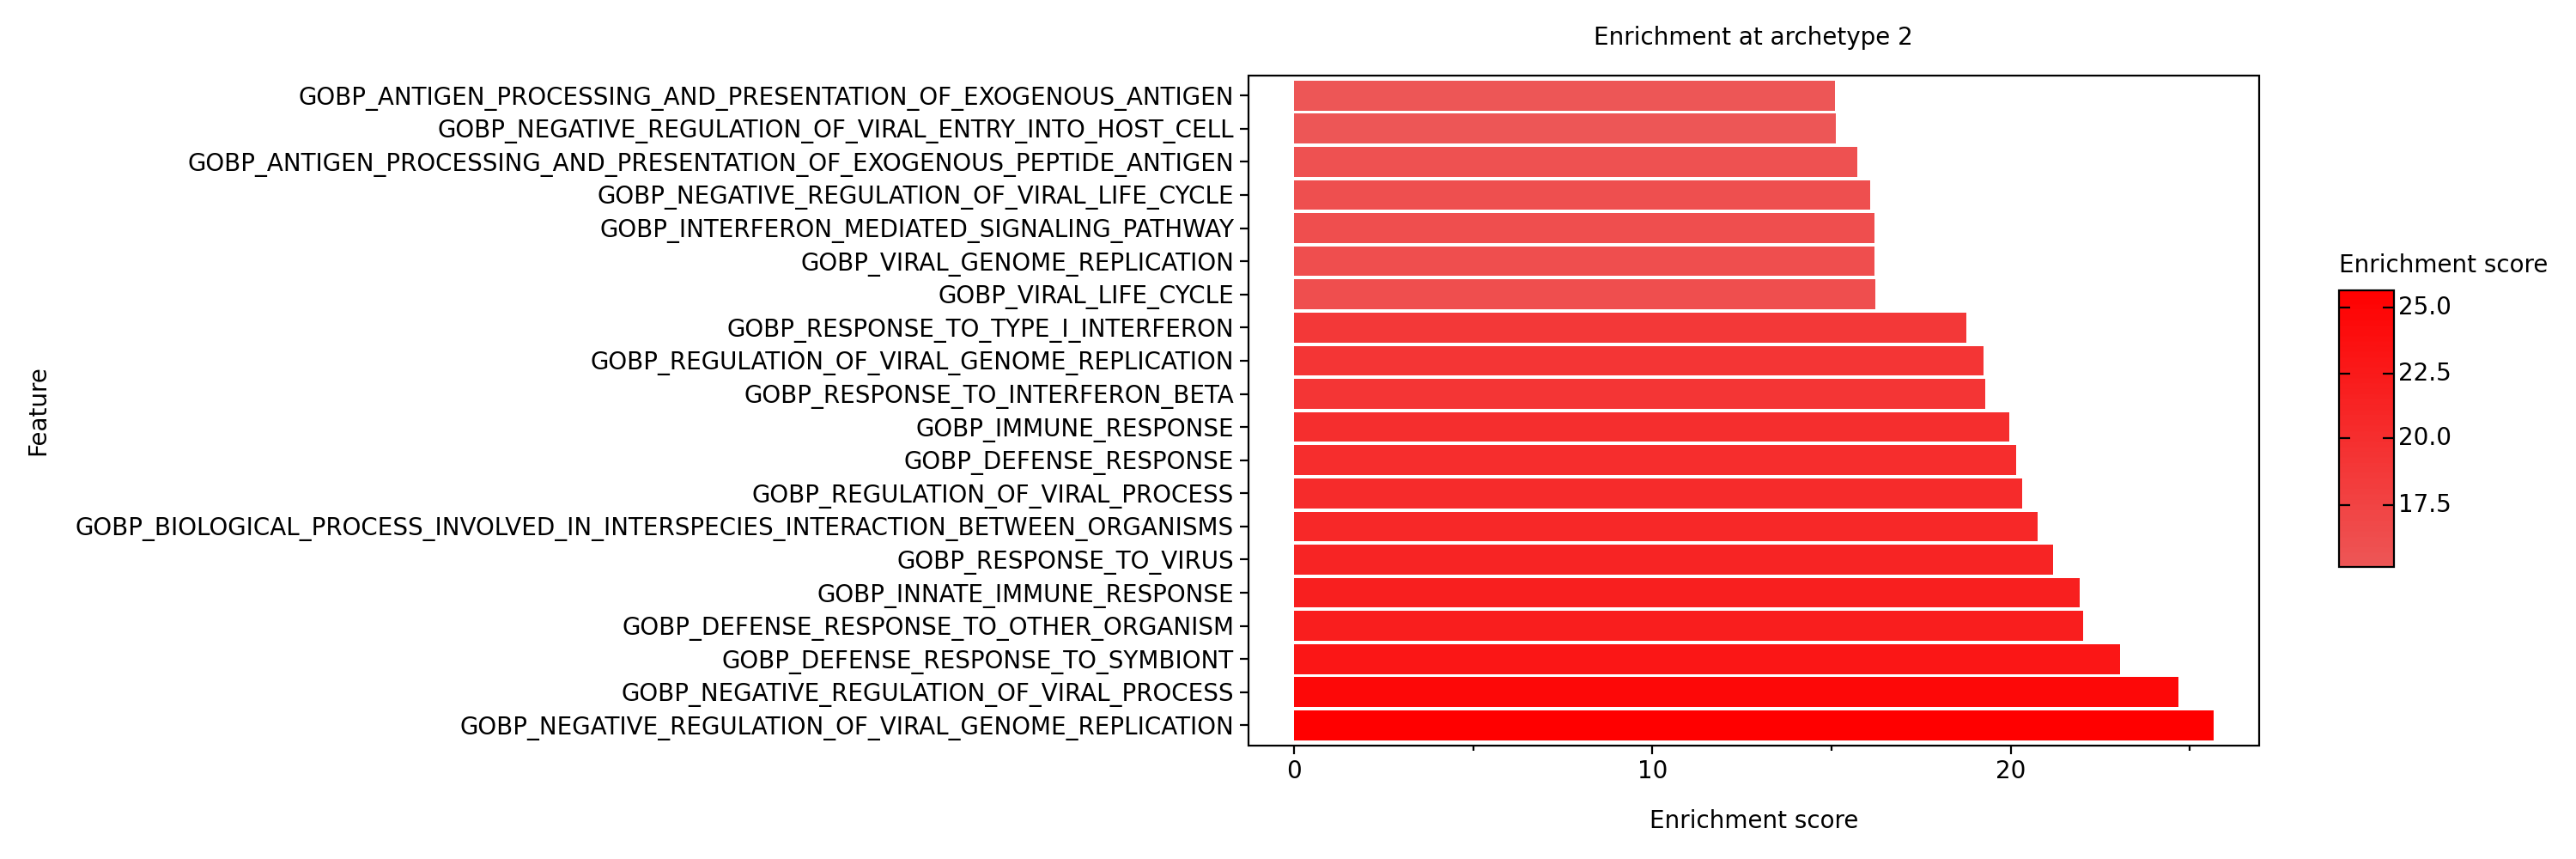

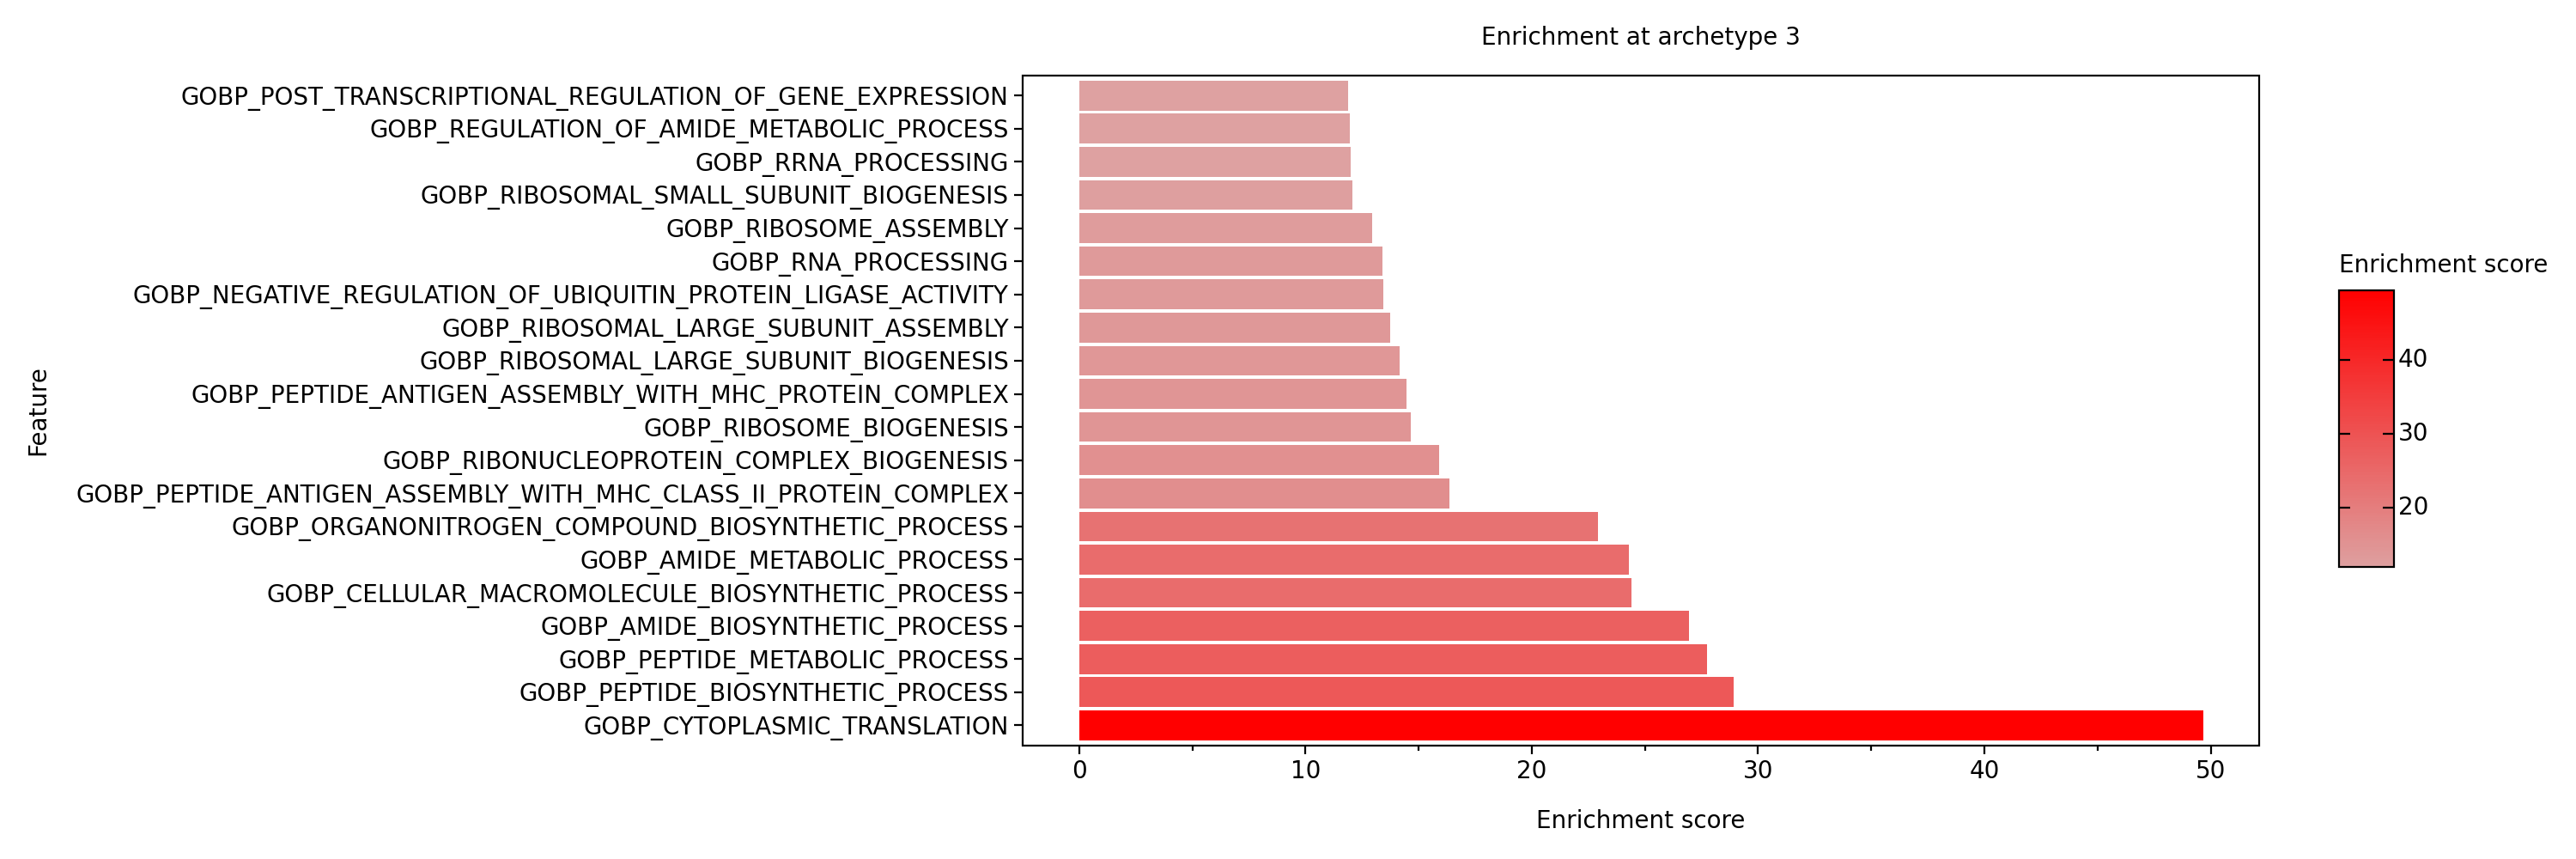

In [47]:
pt.barplot_functional_enrichment(top_processes_msigdb)

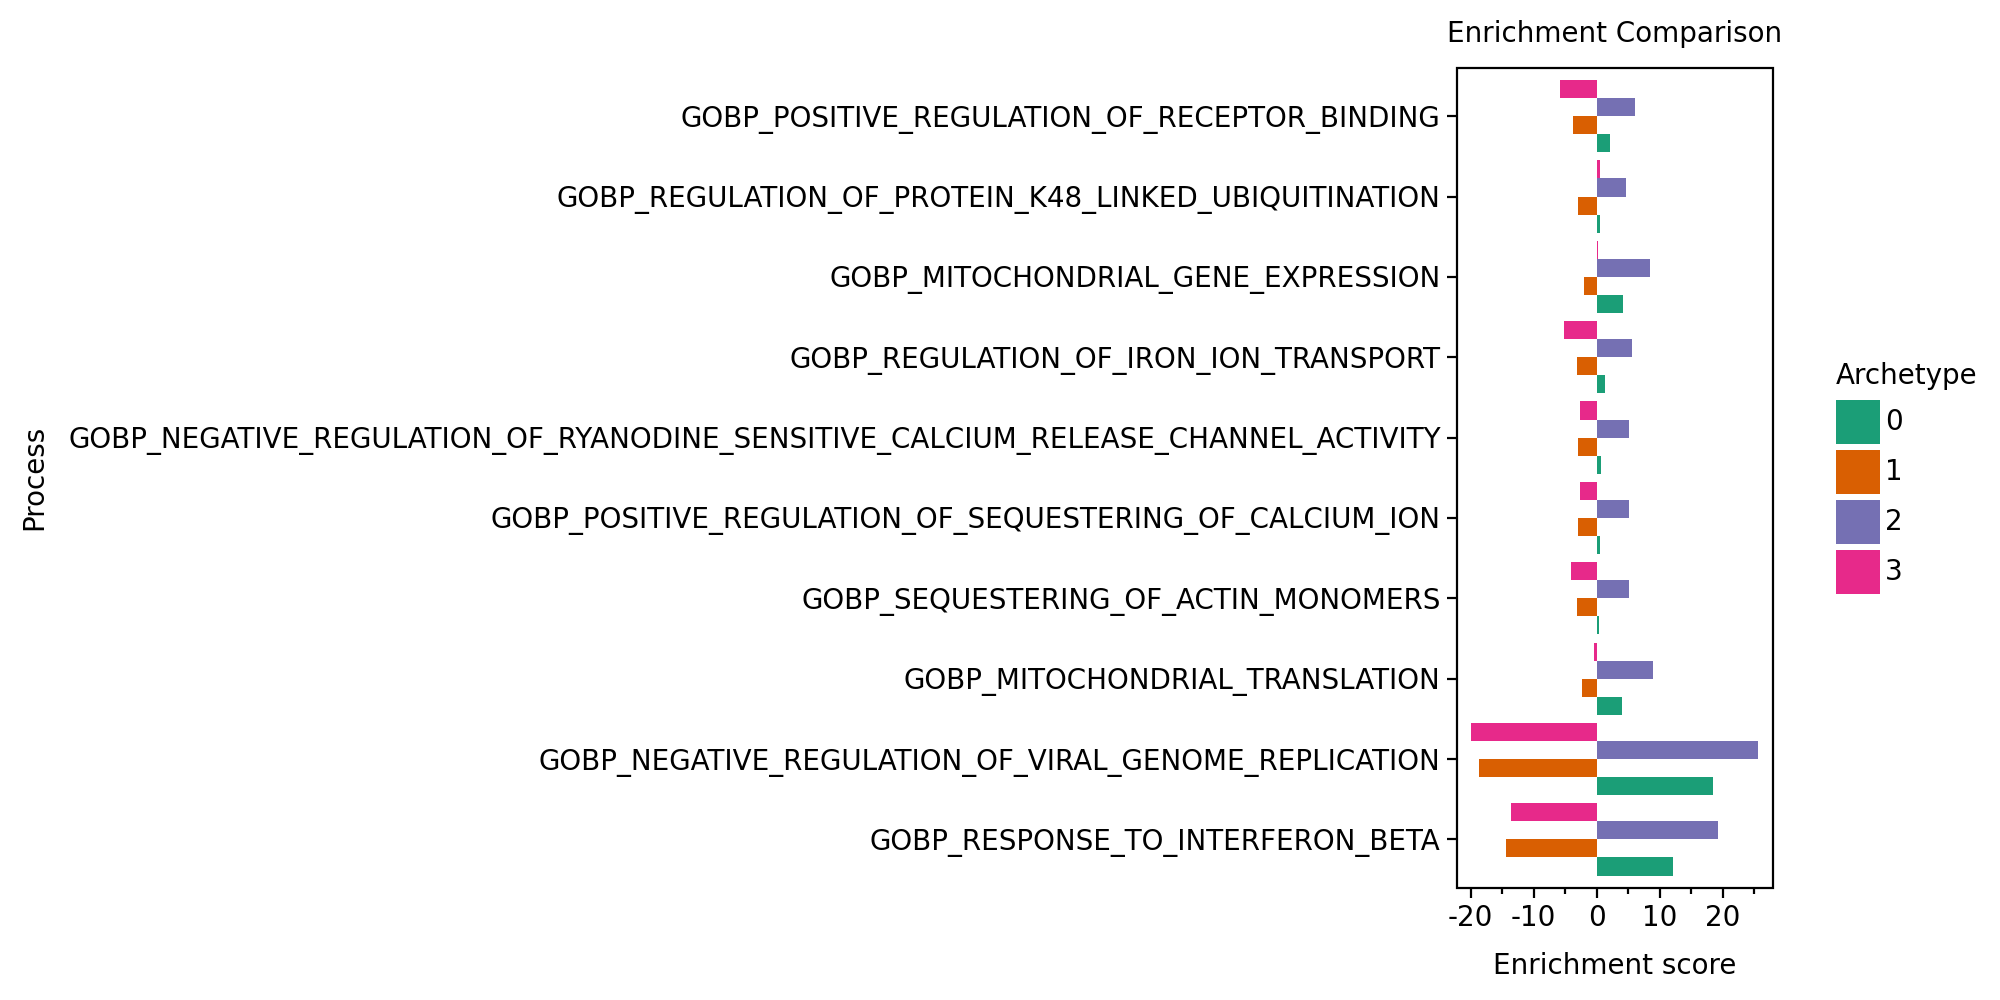

In [48]:
pt.barplot_enrichment_comparison(specific_processes_msigdb[2])

## Functional Enrichment Cytosig

We will repeat the same process now for other resources:

First access the Cytosig data:

In [49]:
cytosig_url = "https://raw.githubusercontent.com/data2intelligence/CytoSig/master/CytoSig/signature.centroid"
cytosig = pd.read_csv(cytosig_url, sep="\t")
cytosig = cytosig.reset_index().rename(columns={"index": "gene"})
cytosig = cytosig.melt(id_vars=["gene"], var_name="cluster", value_name="expression")
cytosig = cytosig.rename({"cluster": "source", "expression": "weight", "gene": "target"}, axis=1)
cytosig["target-source"] = [t + "-" + s for t, s in zip(cytosig["target"], cytosig["source"])]

Now we run enrichment again with decoupler:

In [50]:
acts_ulm_est_cyt, acts_ulm_est_p_cyt = dc.run_ulm(mat = archetype_expression,
                                                  net = cytosig,
                                                  weight = "weight",
                                                  source="source",
                                                  target="target")

acts_ulm_est_cyt

,Activin A,BDNF,BMP2,BMP4,BMP6,CD40L,CXCL12,EGF,FGF2,GCSF,...,MCSF,NO,OSM,TGFB1,TGFB3,TNFA,TRAIL,TWEAK,VEGFA,WNT3A
0,4.631682,8.466931,6.001428,6.131729,-9.679097,12.798533,10.954555,14.175149,7.979813,6.794724,...,0.953405,9.719267,18.802841,-1.888720,3.329241,24.264668,15.675092,16.534336,10.942391,-6.919549
1,-3.924741,-2.726860,-2.260591,-7.908637,5.096923,-6.858396,-8.310857,-0.543858,-7.495856,-5.799999,...,-11.567139,-6.035803,-15.173653,0.419235,-0.145181,-15.084778,-4.260556,-8.718311,-0.942975,3.330035
2,1.561520,3.172391,2.353461,5.149254,-4.972589,-6.251480,0.768992,-1.950210,2.026341,0.270268,...,2.489020,-4.721488,13.069192,-6.858054,-9.861809,3.209209,-4.411265,1.483378,-5.548844,-3.475177
3,-4.190672,-2.569884,-0.920264,-6.662569,-2.050915,-0.484611,-1.646264,4.606673,-2.309176,-6.337020,...,-6.106660,-6.103199,-5.895823,-1.516394,1.420967,-4.349096,4.079686,2.062907,1.904184,-1.035932


Extract top processes:

In [51]:
top_processes_cyt = pt.extract_enriched_processes(est=acts_ulm_est_cyt, 
                                                  pval=acts_ulm_est_p_cyt, 
                                                  order="desc", 
                                                  n=20, 
                                                  p_threshold=0.05)

In [52]:
specific_processes_cyt = pt.extract_specific_processes(est=acts_ulm_est_cyt, 
                                                       pval=acts_ulm_est_p_cyt, 
                                                       n=10, 
                                                       p_threshold=0.05)

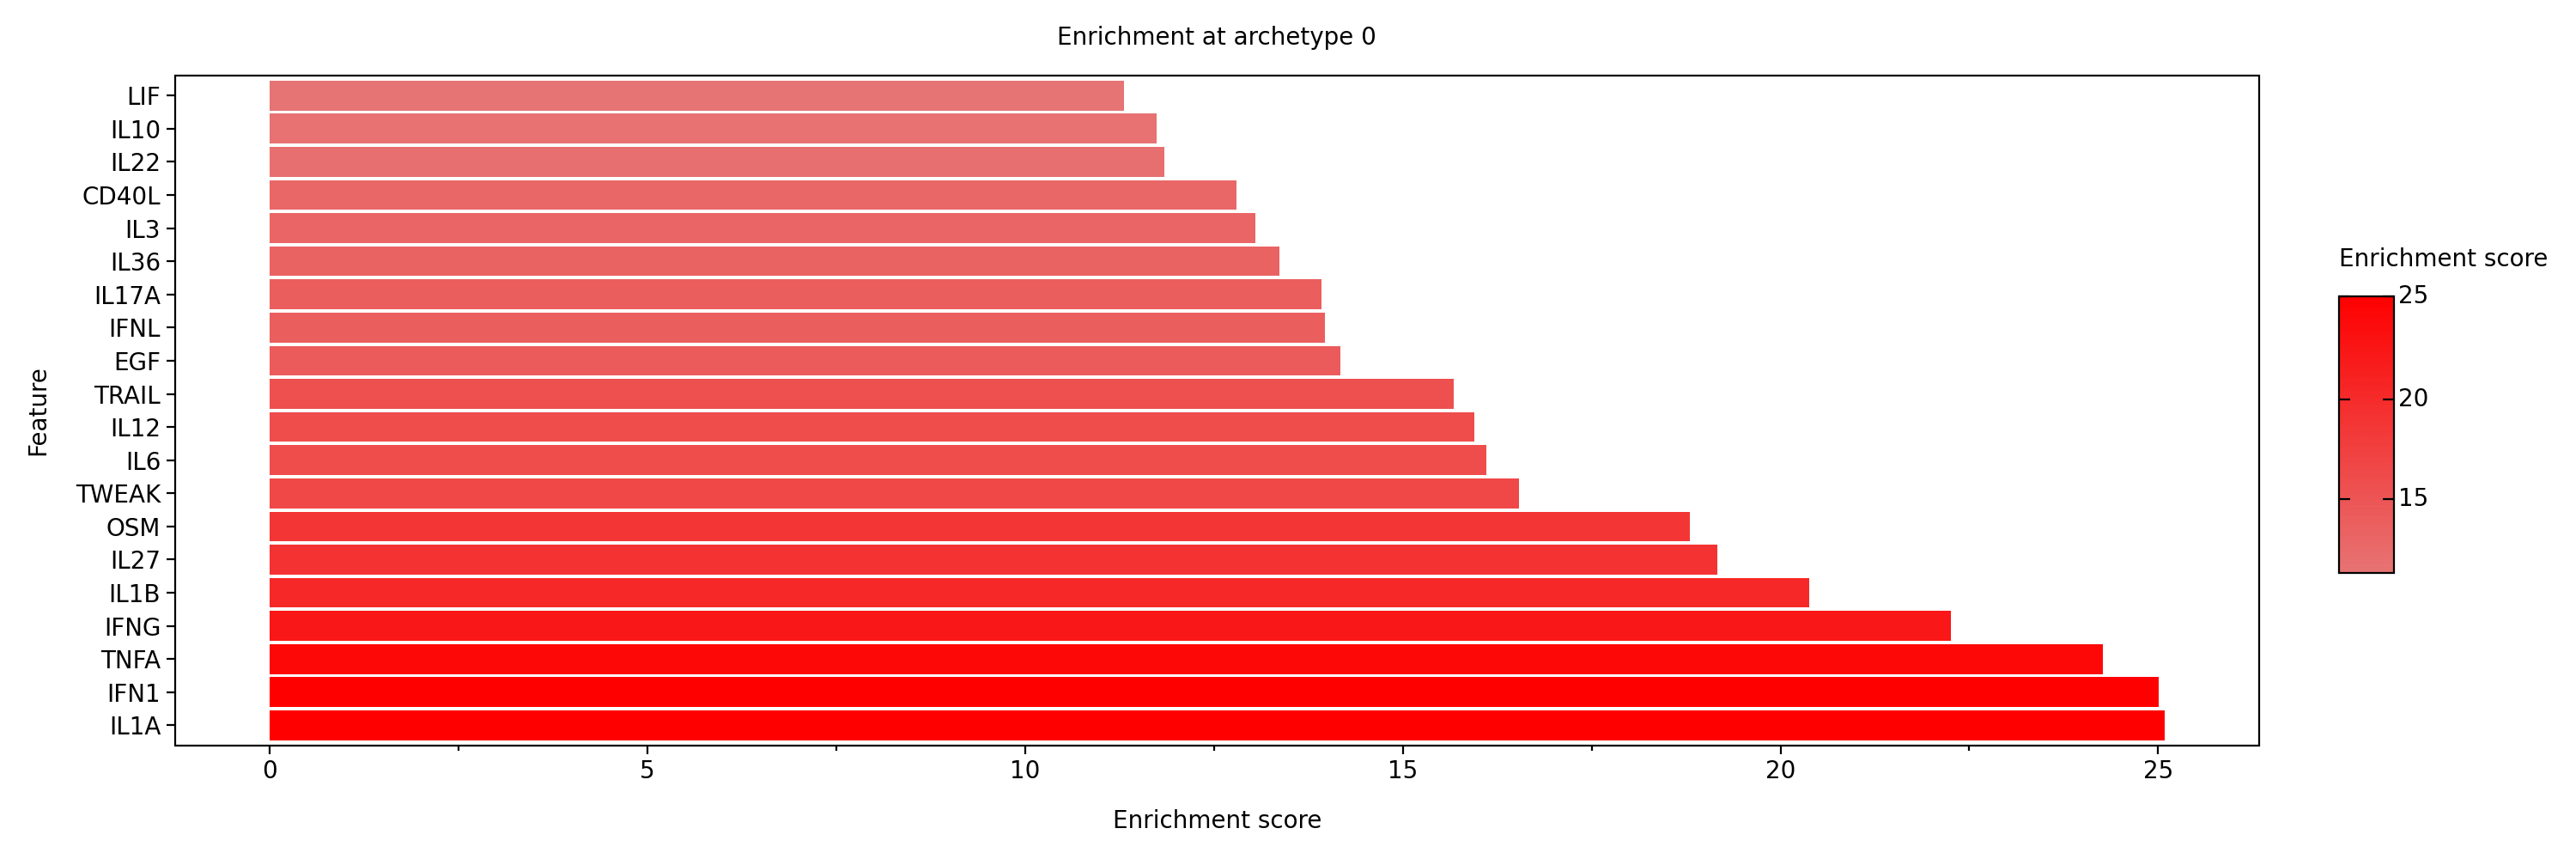

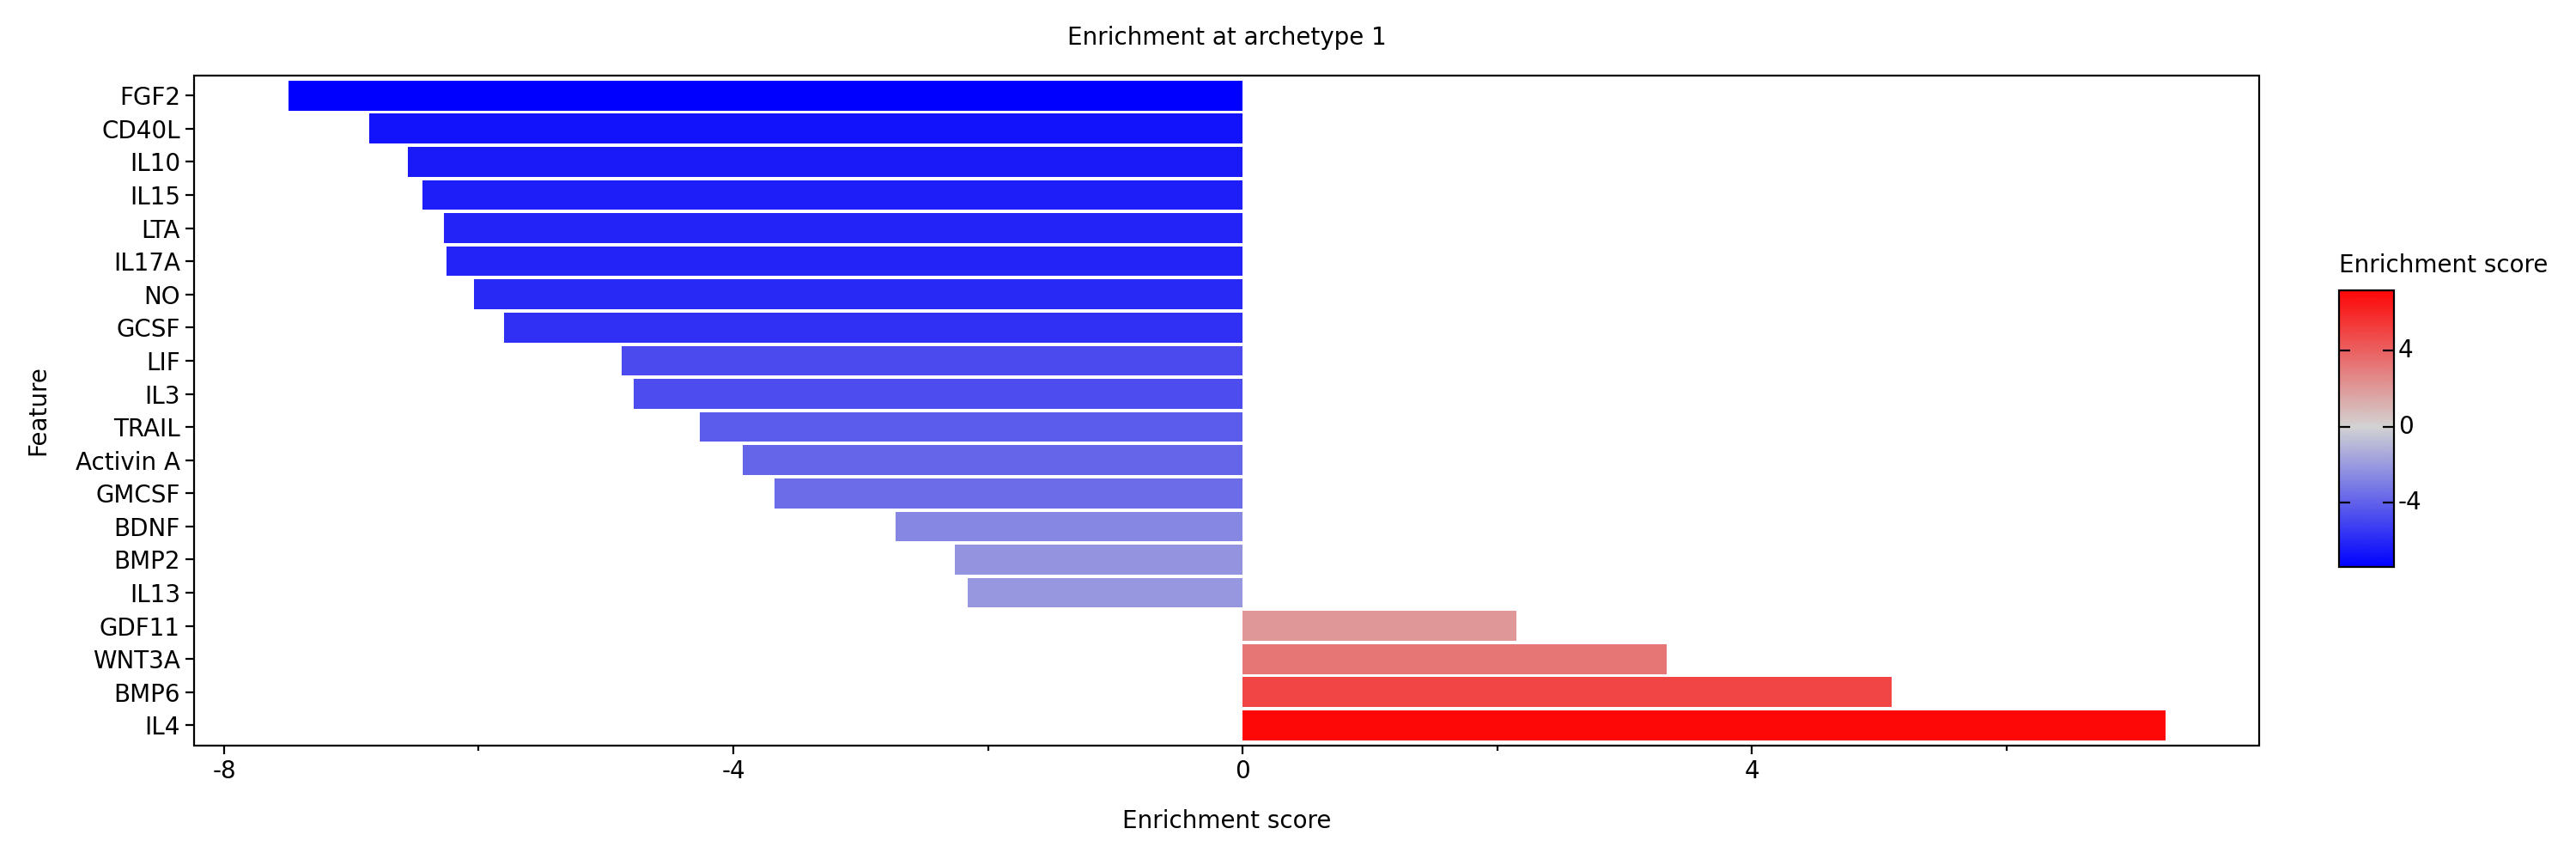

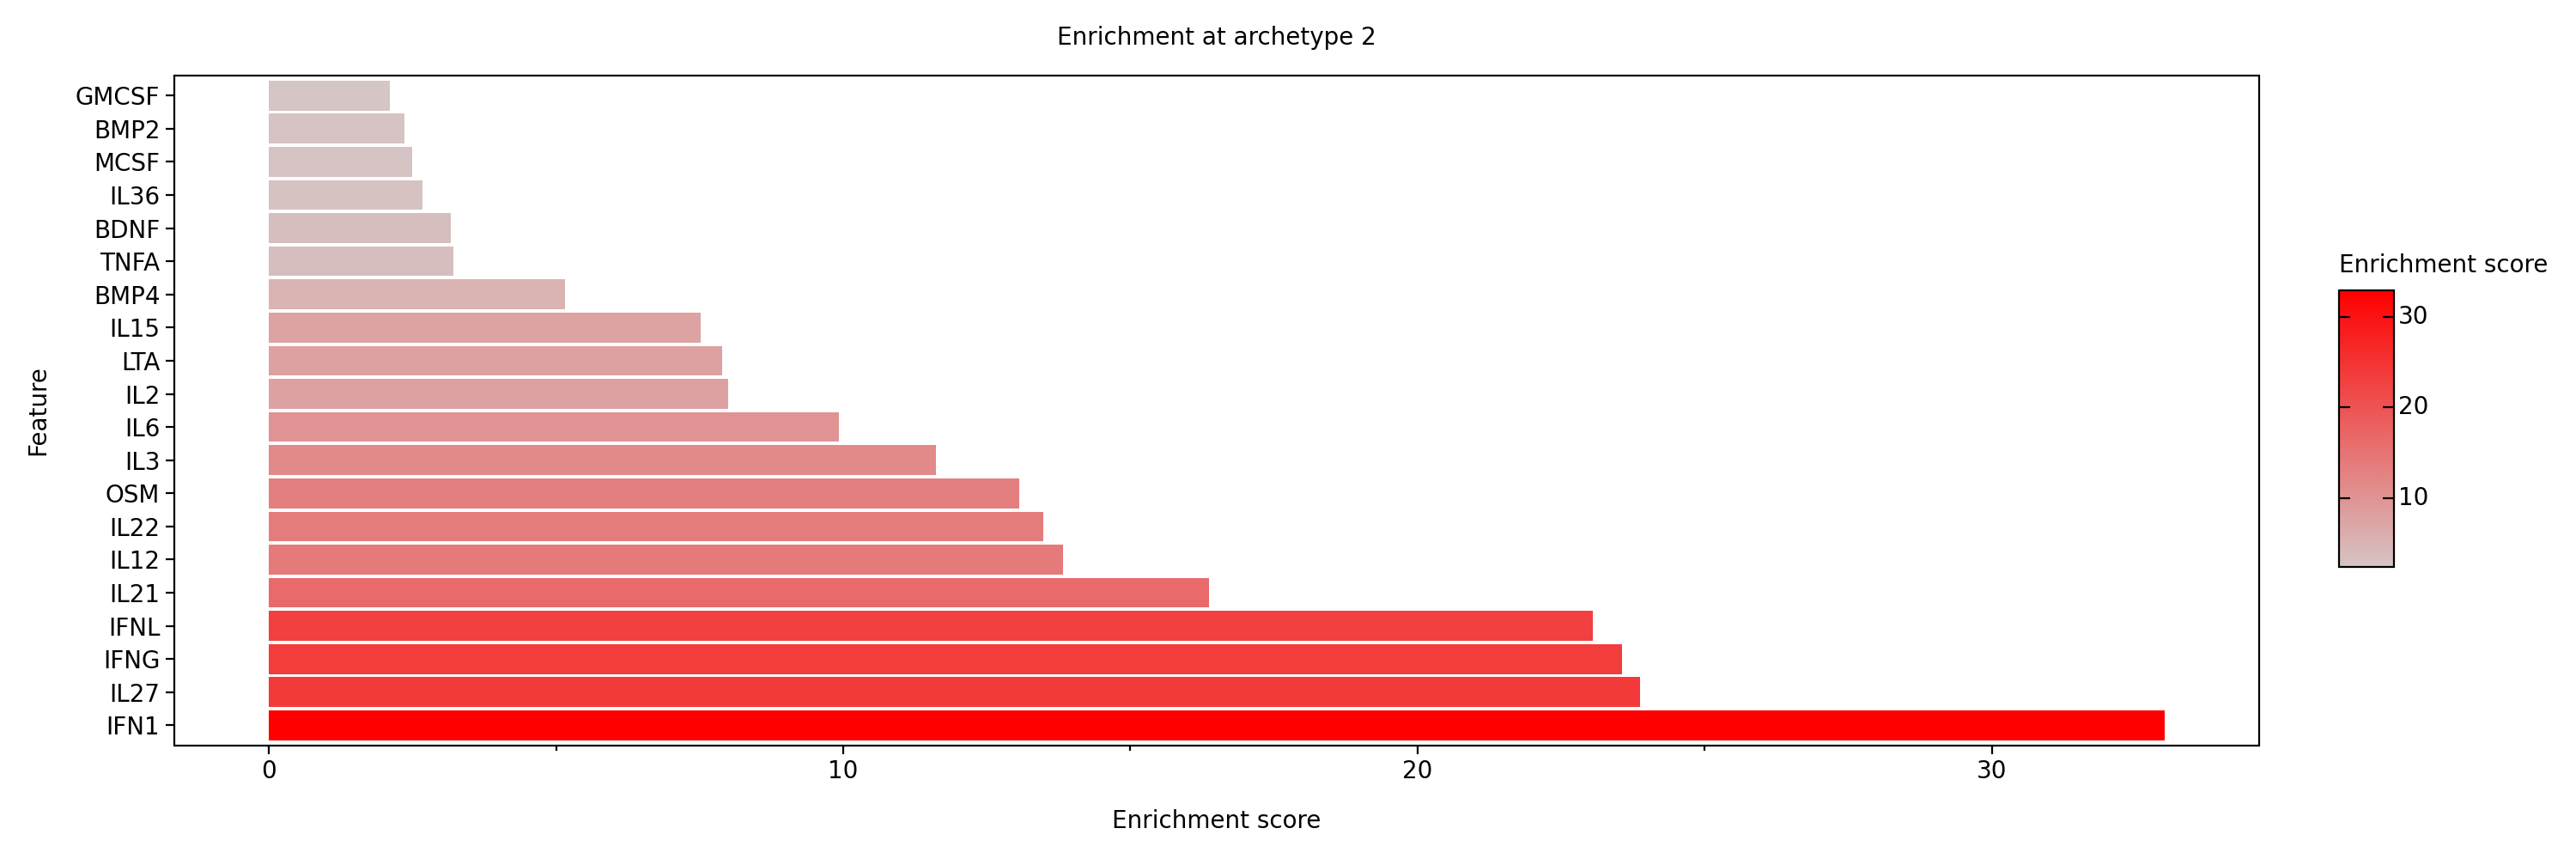

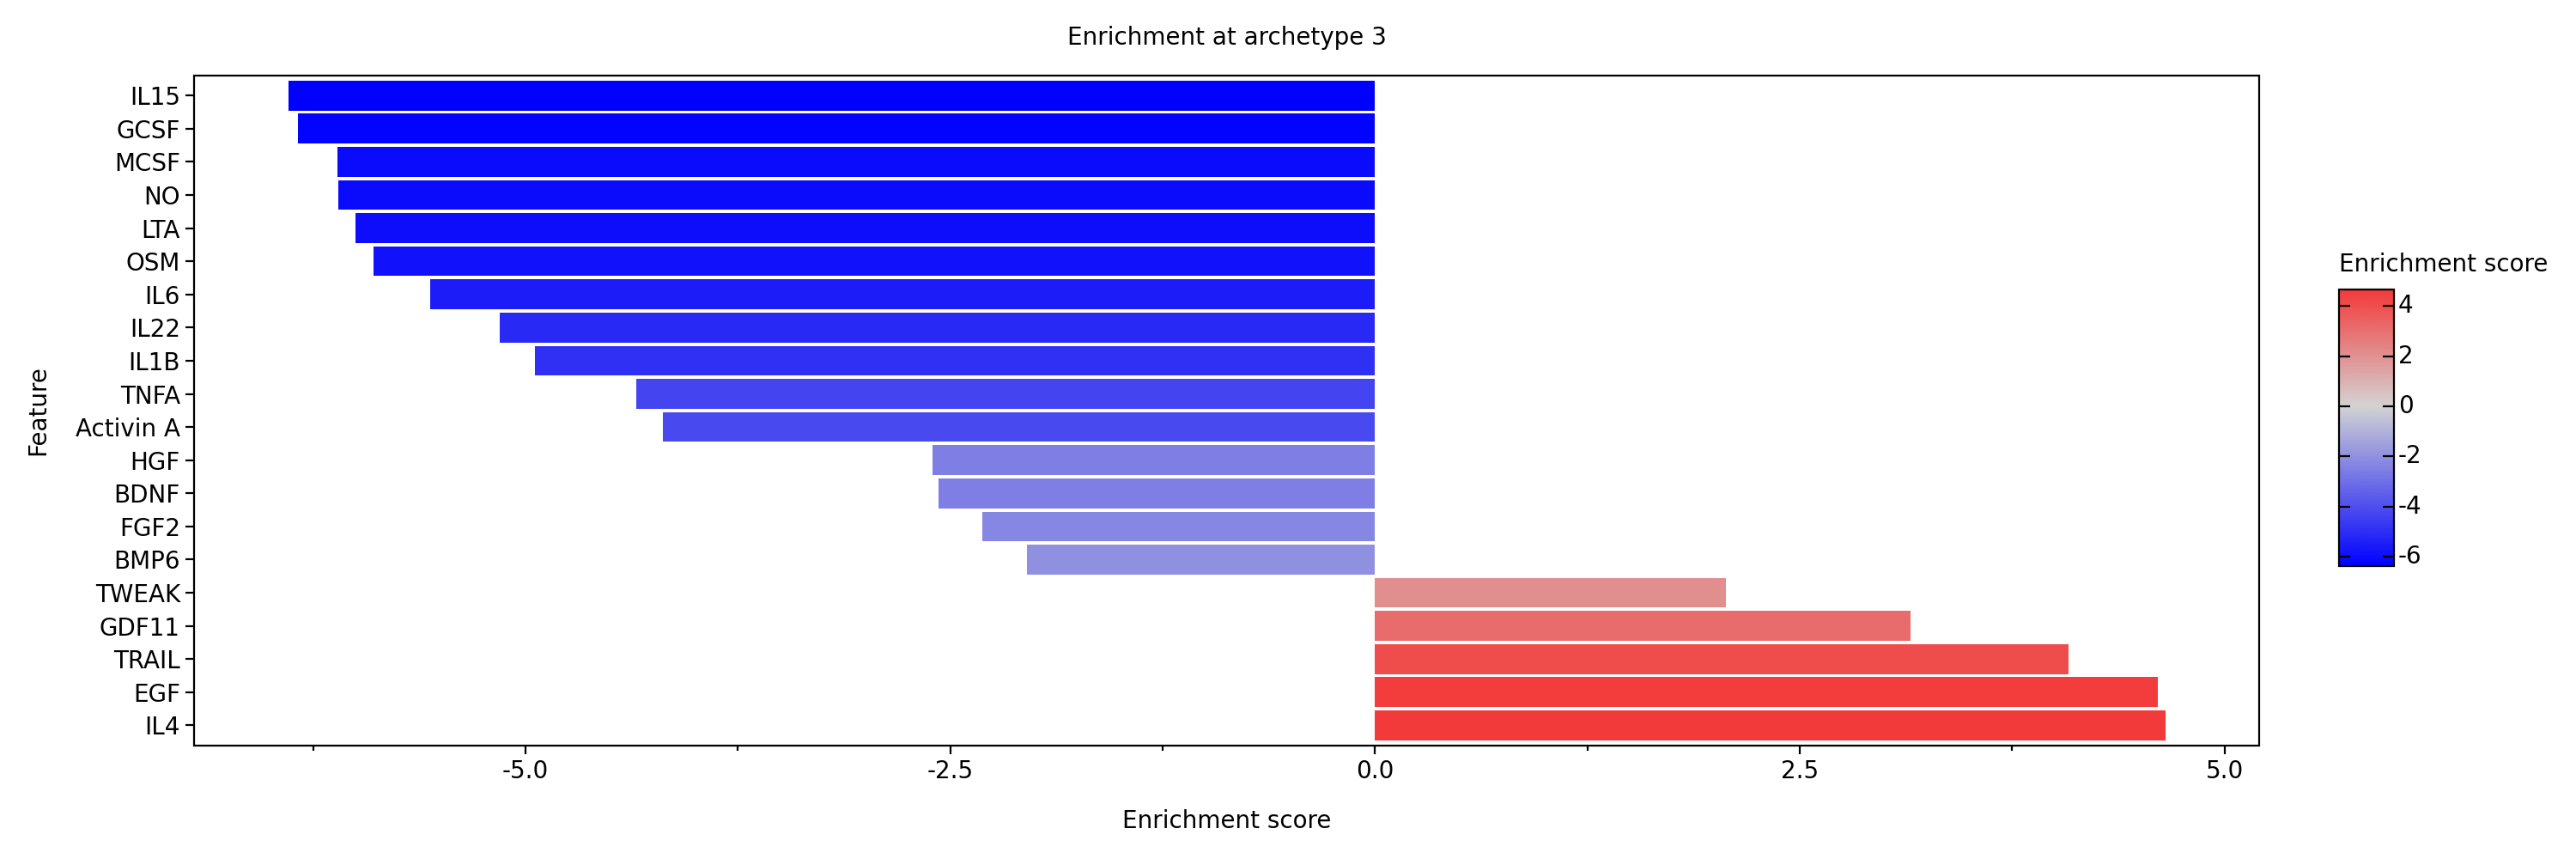

In [53]:
pt.barplot_functional_enrichment(top_processes_cyt)

Archetype 2 associated with flare:

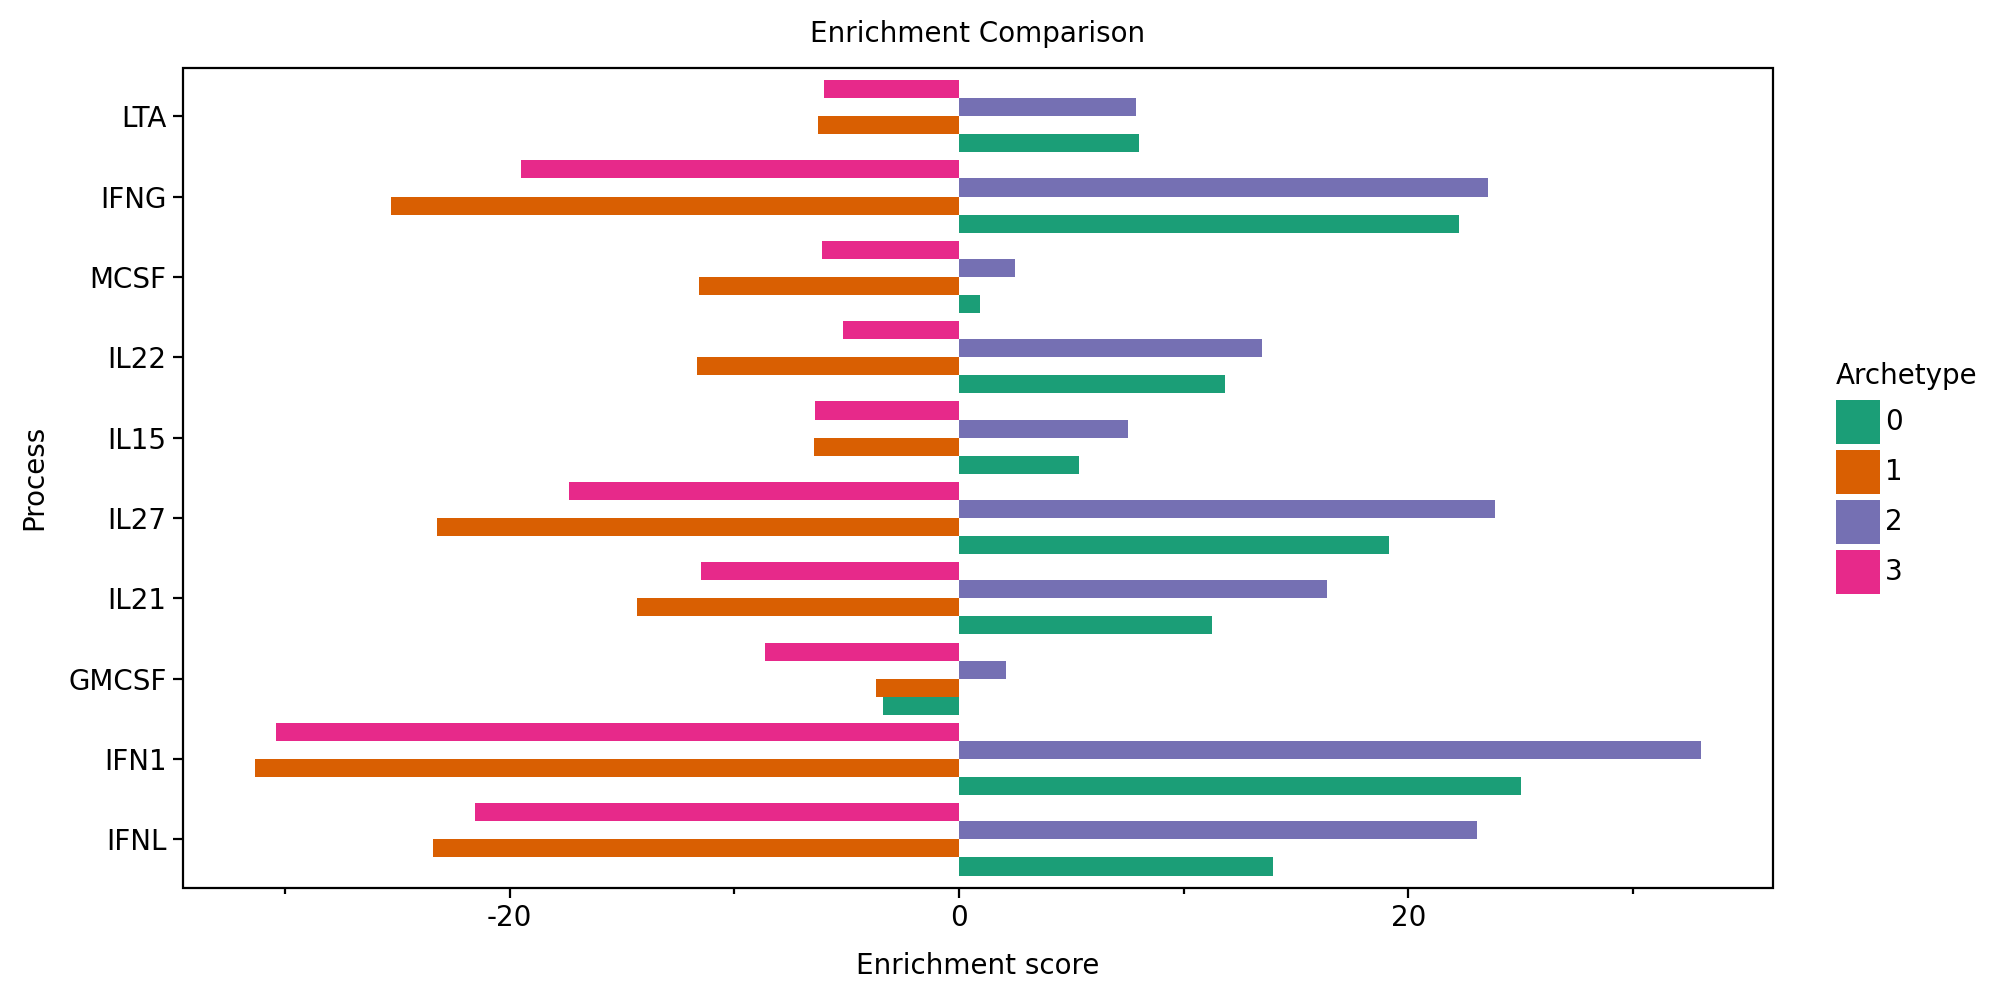

In [54]:
pt.barplot_enrichment_comparison(specific_processes_cyt[2])

## Functional Enrichment CollecTRI

Get resource:

In [55]:
collectri = dc.get_collectri(organism="human", split_complexes=False)
collectri

,source,target,weight
0,ABL1,BAX,1
1,ABL1,BCL2,-1
2,ABL1,BCL6,-1
3,ABL1,CCND2,1
4,ABL1,CDKN1A,1
...,...,...,...
40625,ZXDC,CDKN1C,1
40626,ZXDC,CDKN2A,1
40627,ZXDC,CIITA,1
40628,ZXDC,HLA-E,1


Estimate enrichment:

In [56]:
acts_ulm_est_collectri, acts_ulm_est_p_collectri = dc.run_ulm(mat = archetype_expression,
                                                              net = collectri,
                                                              weight = "weight",
                                                              source = "source",
                                                              target = "target")

acts_ulm_est_collectri

,ABL1,AHR,AIP,AIRE,AP1,APEX1,AR,ARID1A,ARID1B,ARID3A,...,ZNF382,ZNF384,ZNF395,ZNF410,ZNF436,ZNF699,ZNF76,ZNF804A,ZNF91,ZXDC
0,5.705778,8.766658,-0.641403,10.474472,13.959791,4.491247,7.249280,2.247402,-0.445885,2.132984,...,-4.186429,2.223784,1.555673,0.669756,1.537702,0.466455,-1.355000,1.889477,5.709515,1.155111
1,-3.757343,-5.364671,-0.015578,-3.246321,-7.574339,-1.996150,-1.339921,-1.900266,0.048363,-2.184284,...,1.345819,0.314113,-2.596929,0.537178,-0.498592,0.602496,2.400193,0.448600,-2.512855,1.251906
2,2.184091,2.040984,0.265231,-2.019472,4.871614,0.730943,0.211800,1.303661,-0.426773,1.949100,...,0.893452,-1.148101,4.648964,-0.133283,0.521995,-0.778039,-1.012656,-0.458452,1.524504,-0.330459
3,-1.369278,-0.133967,0.226582,0.628851,0.229480,-0.365120,2.231558,-1.016728,-0.432959,-2.072009,...,-1.891023,-0.296877,-2.531843,0.792686,0.305506,1.016932,0.934198,-0.182922,-1.204105,-1.181736


Extract top scores:

In [57]:
top_processes_collectri = pt.extract_enriched_processes(est=acts_ulm_est_collectri, 
                                                        pval=acts_ulm_est_p_collectri, 
                                                        order="desc", 
                                                        n=20, 
                                                        p_threshold=0.05)

In [58]:
specific_processes_collectri = pt.extract_specific_processes(est=acts_ulm_est_collectri, 
                                                             pval=acts_ulm_est_p_collectri, 
                                                             n=10, 
                                                             p_threshold=0.05)

Plot results:

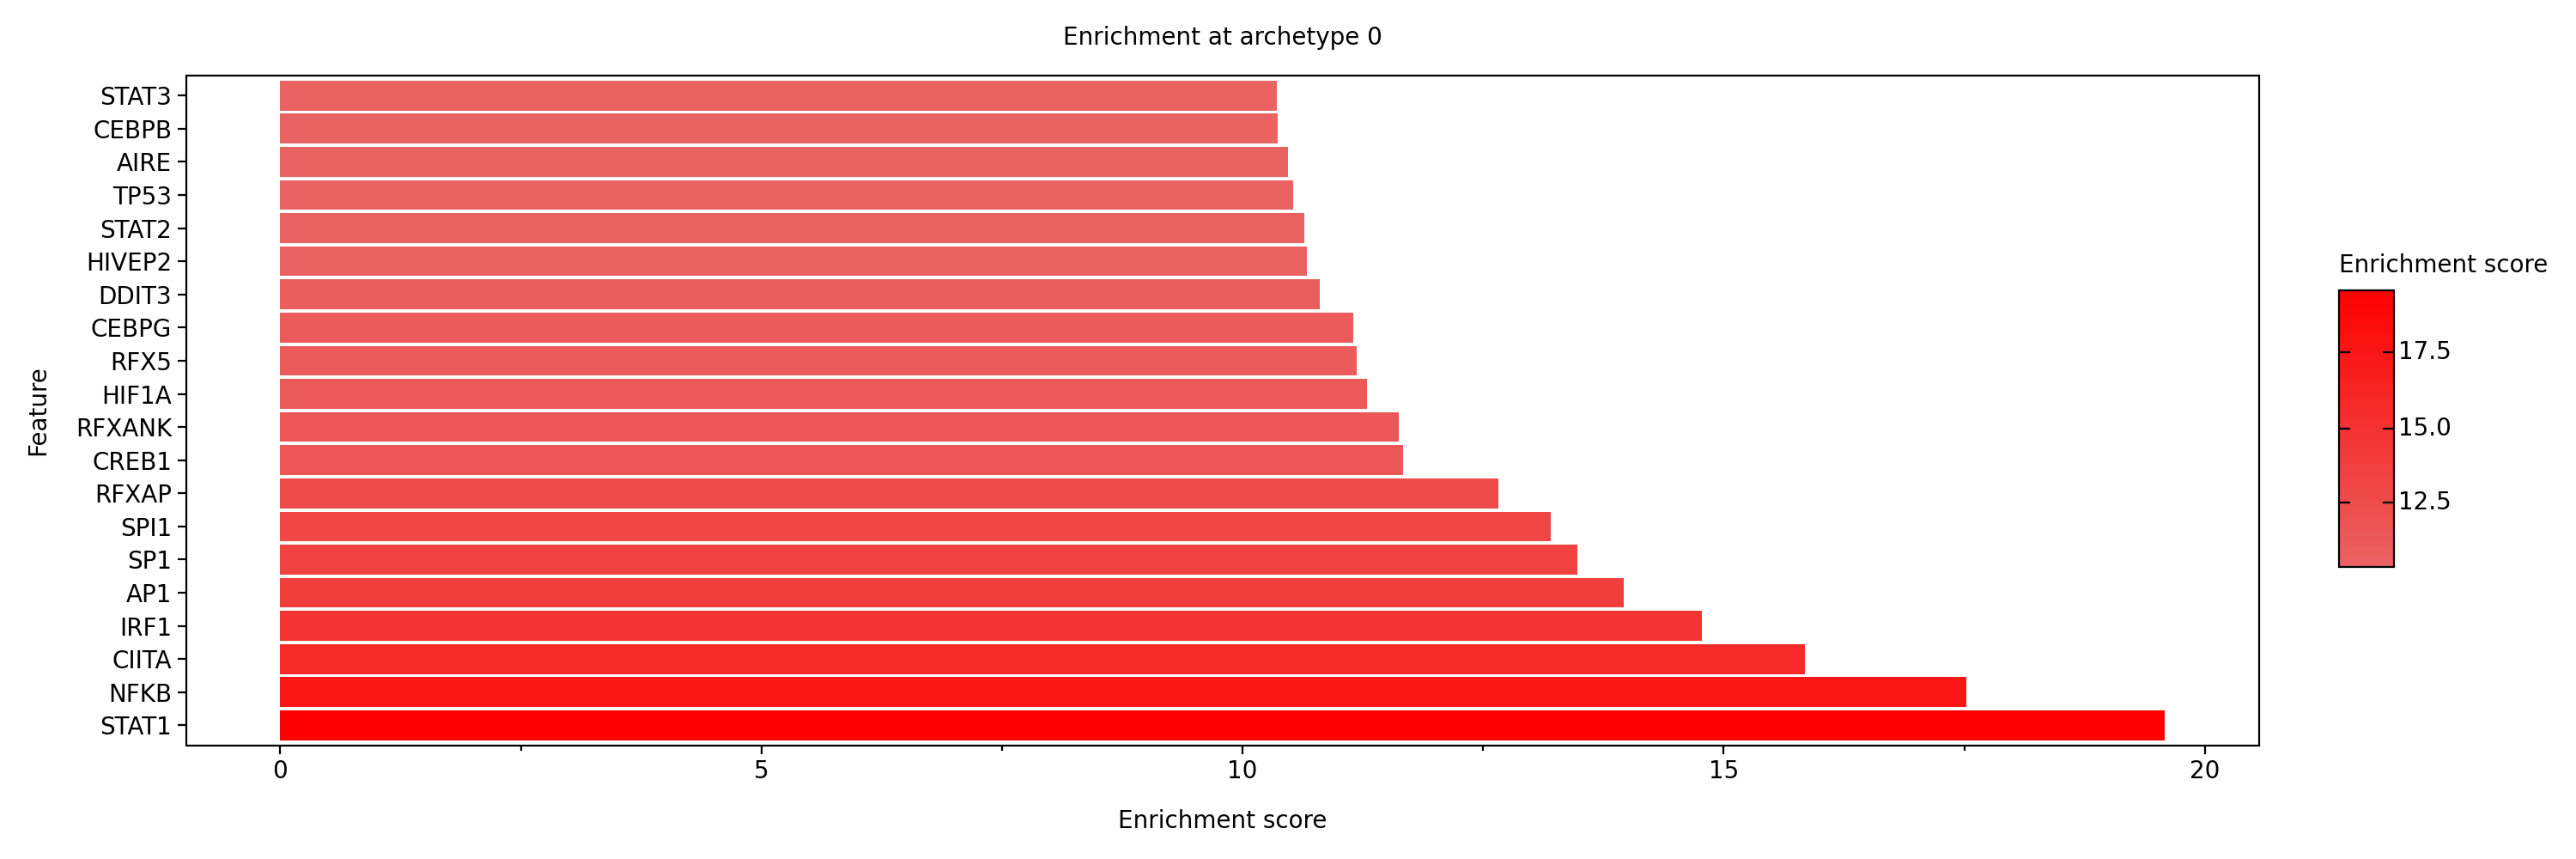

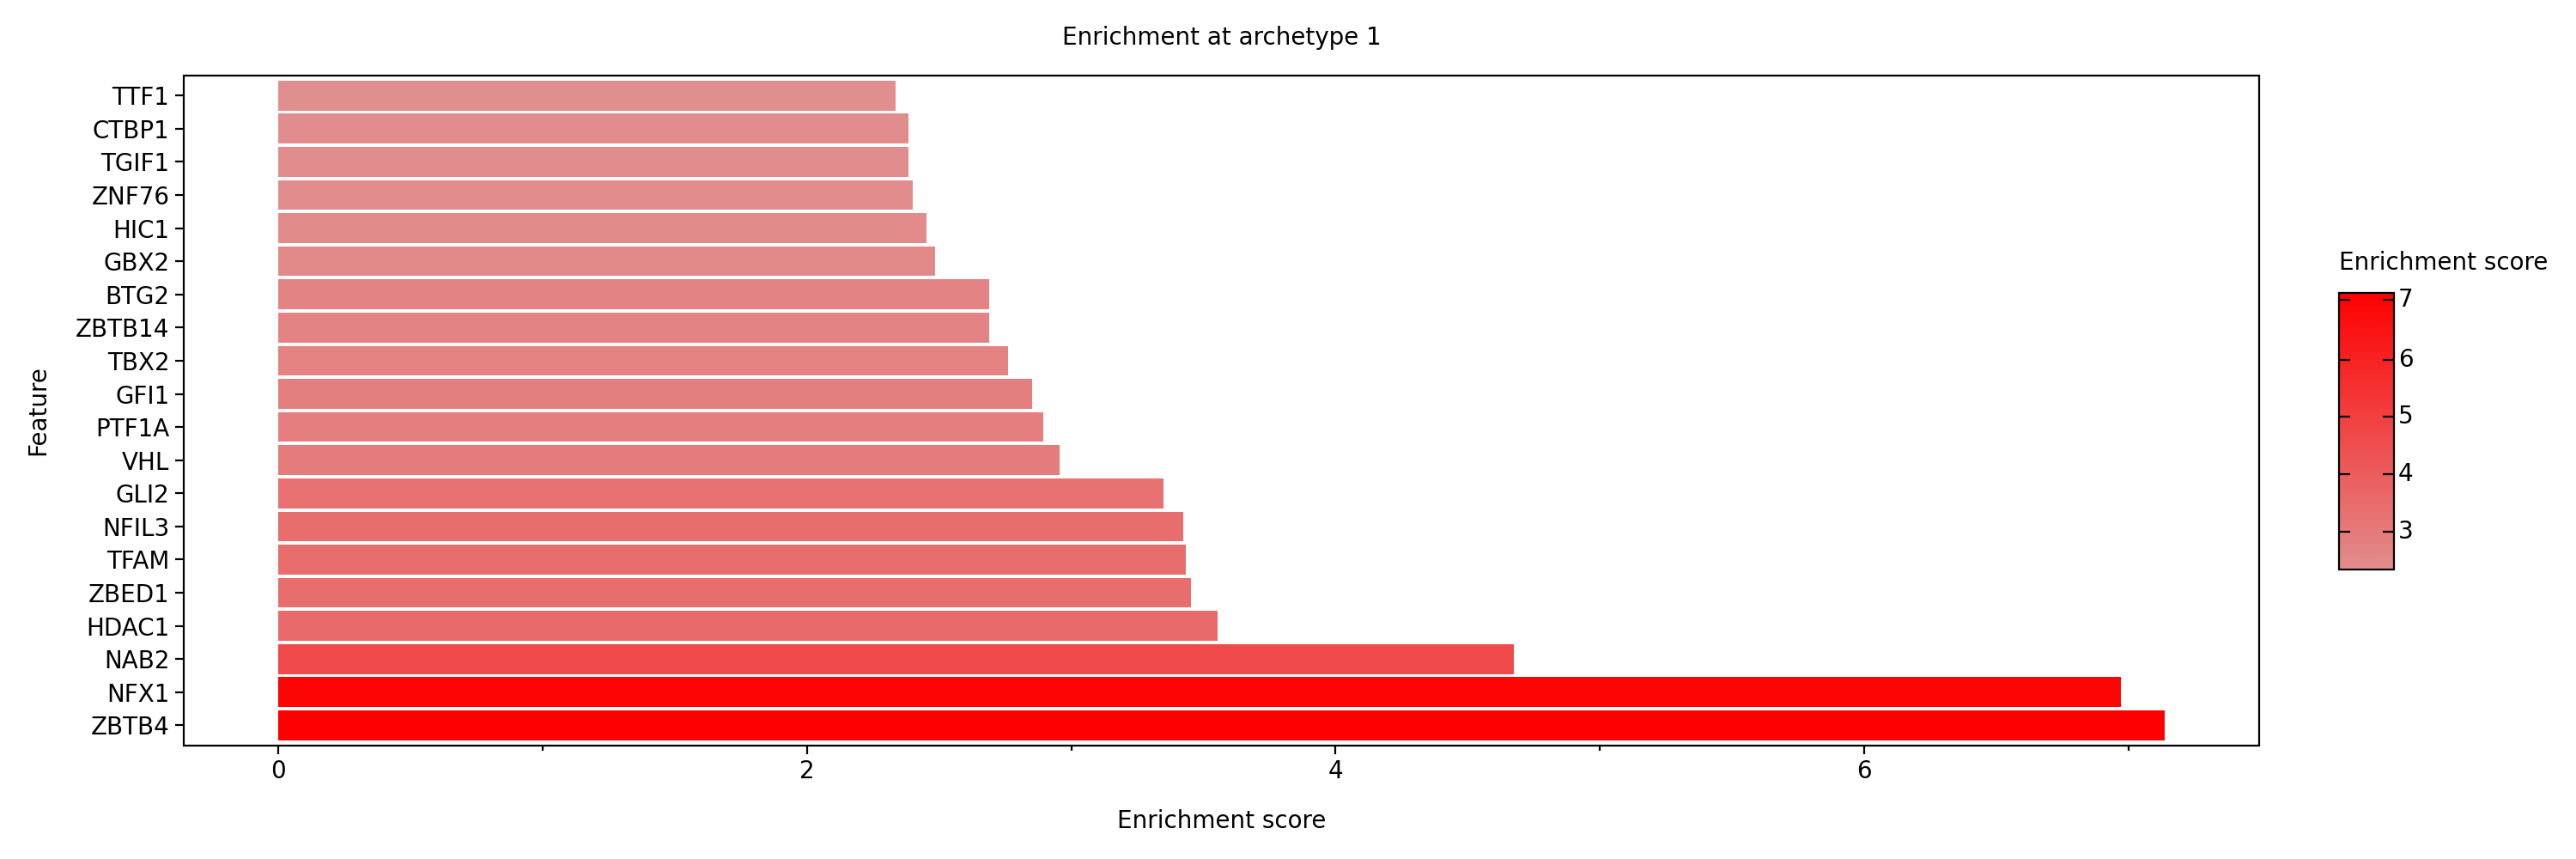

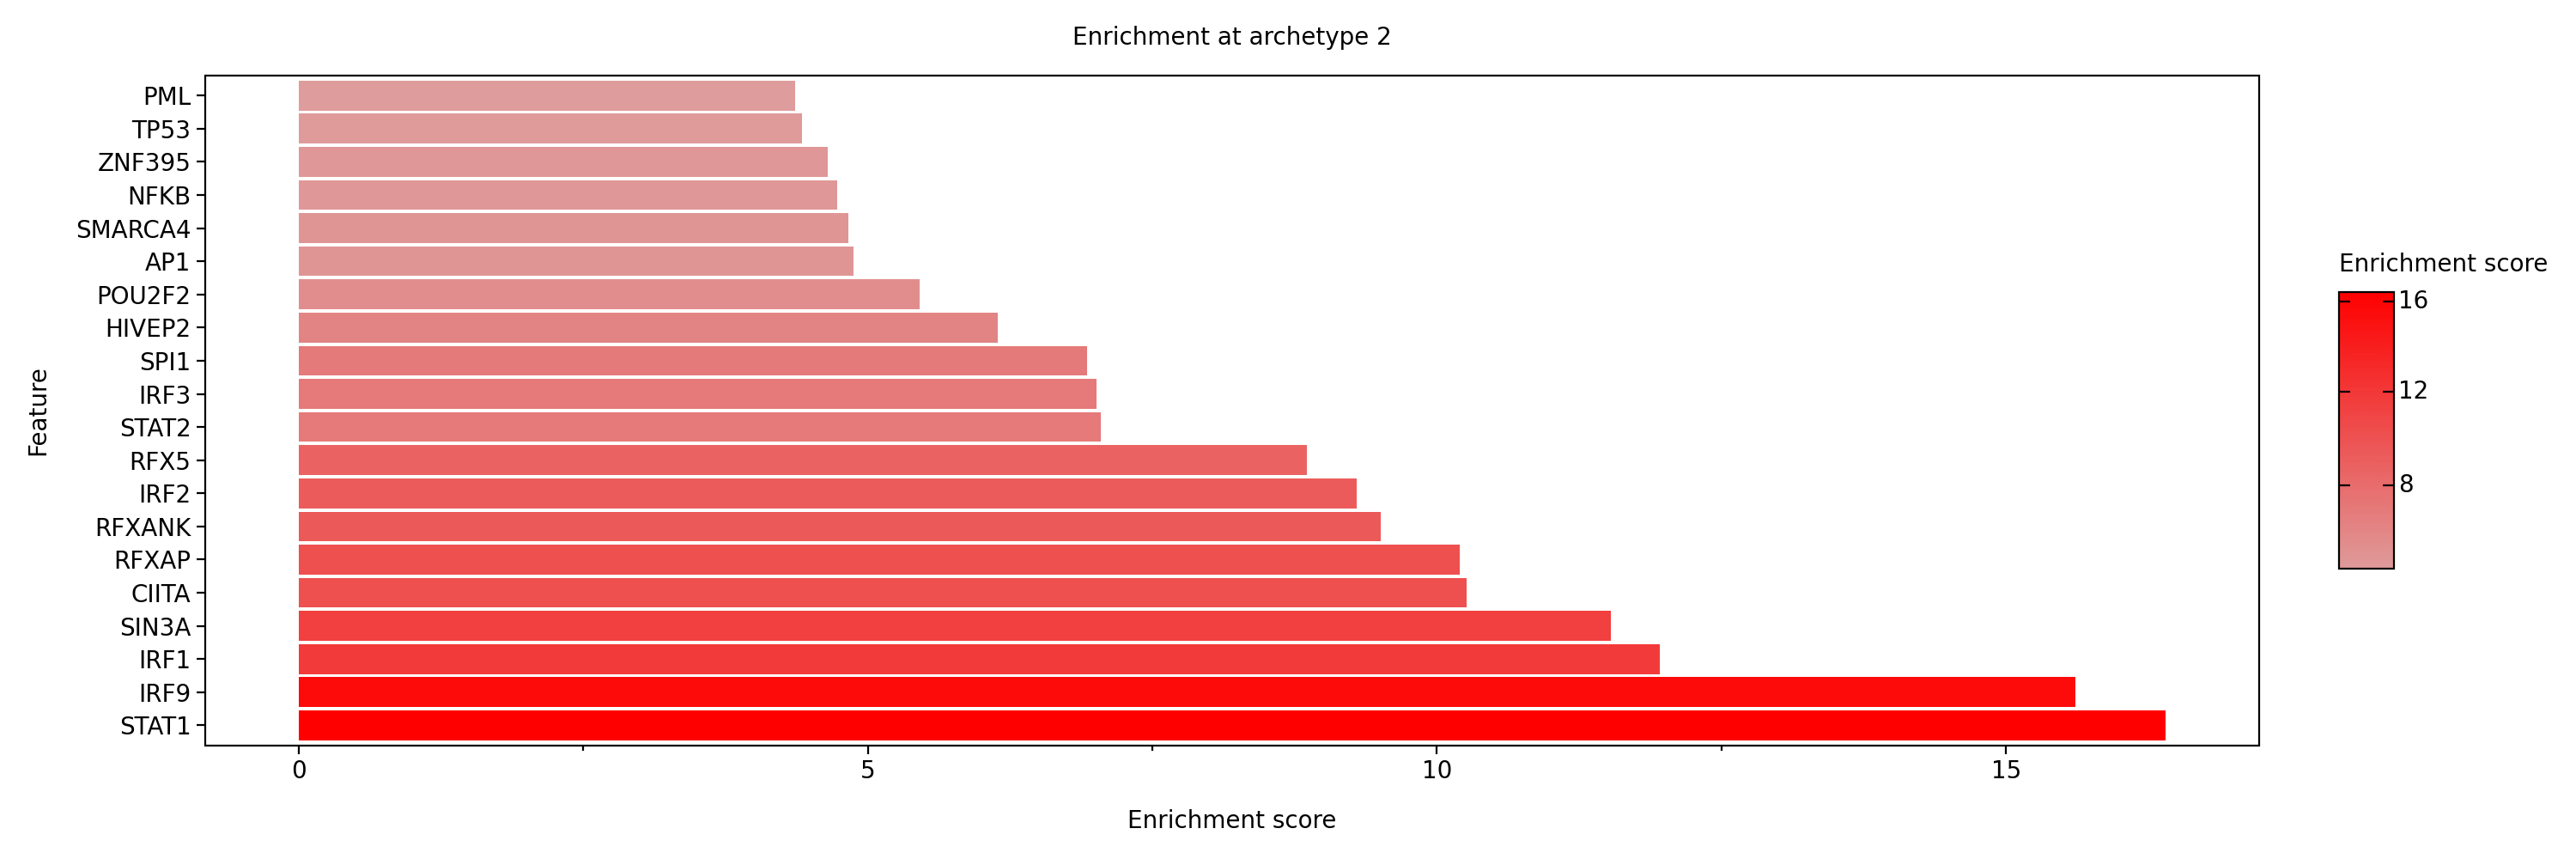

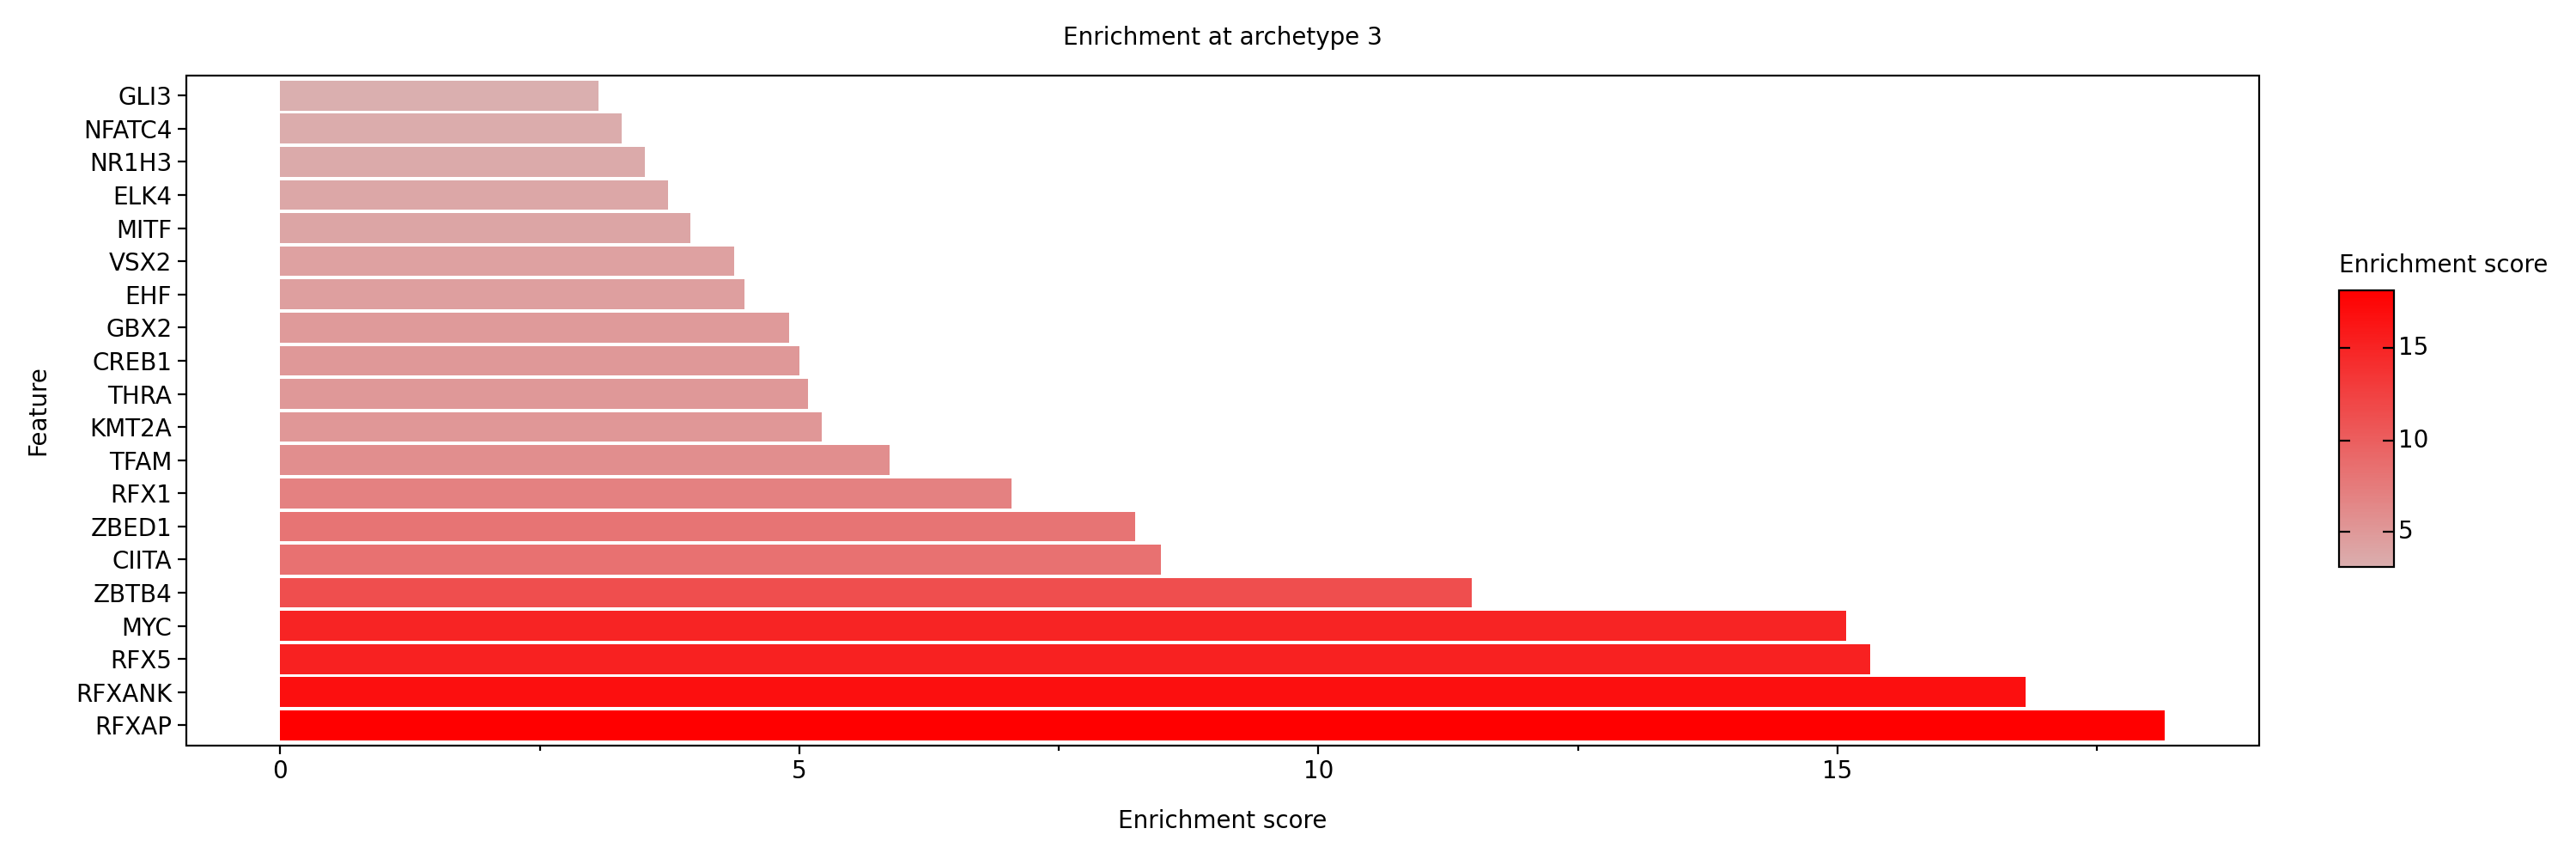

In [59]:
pt.barplot_functional_enrichment(top_processes_collectri)

Archetype 2 associtaed with flare:

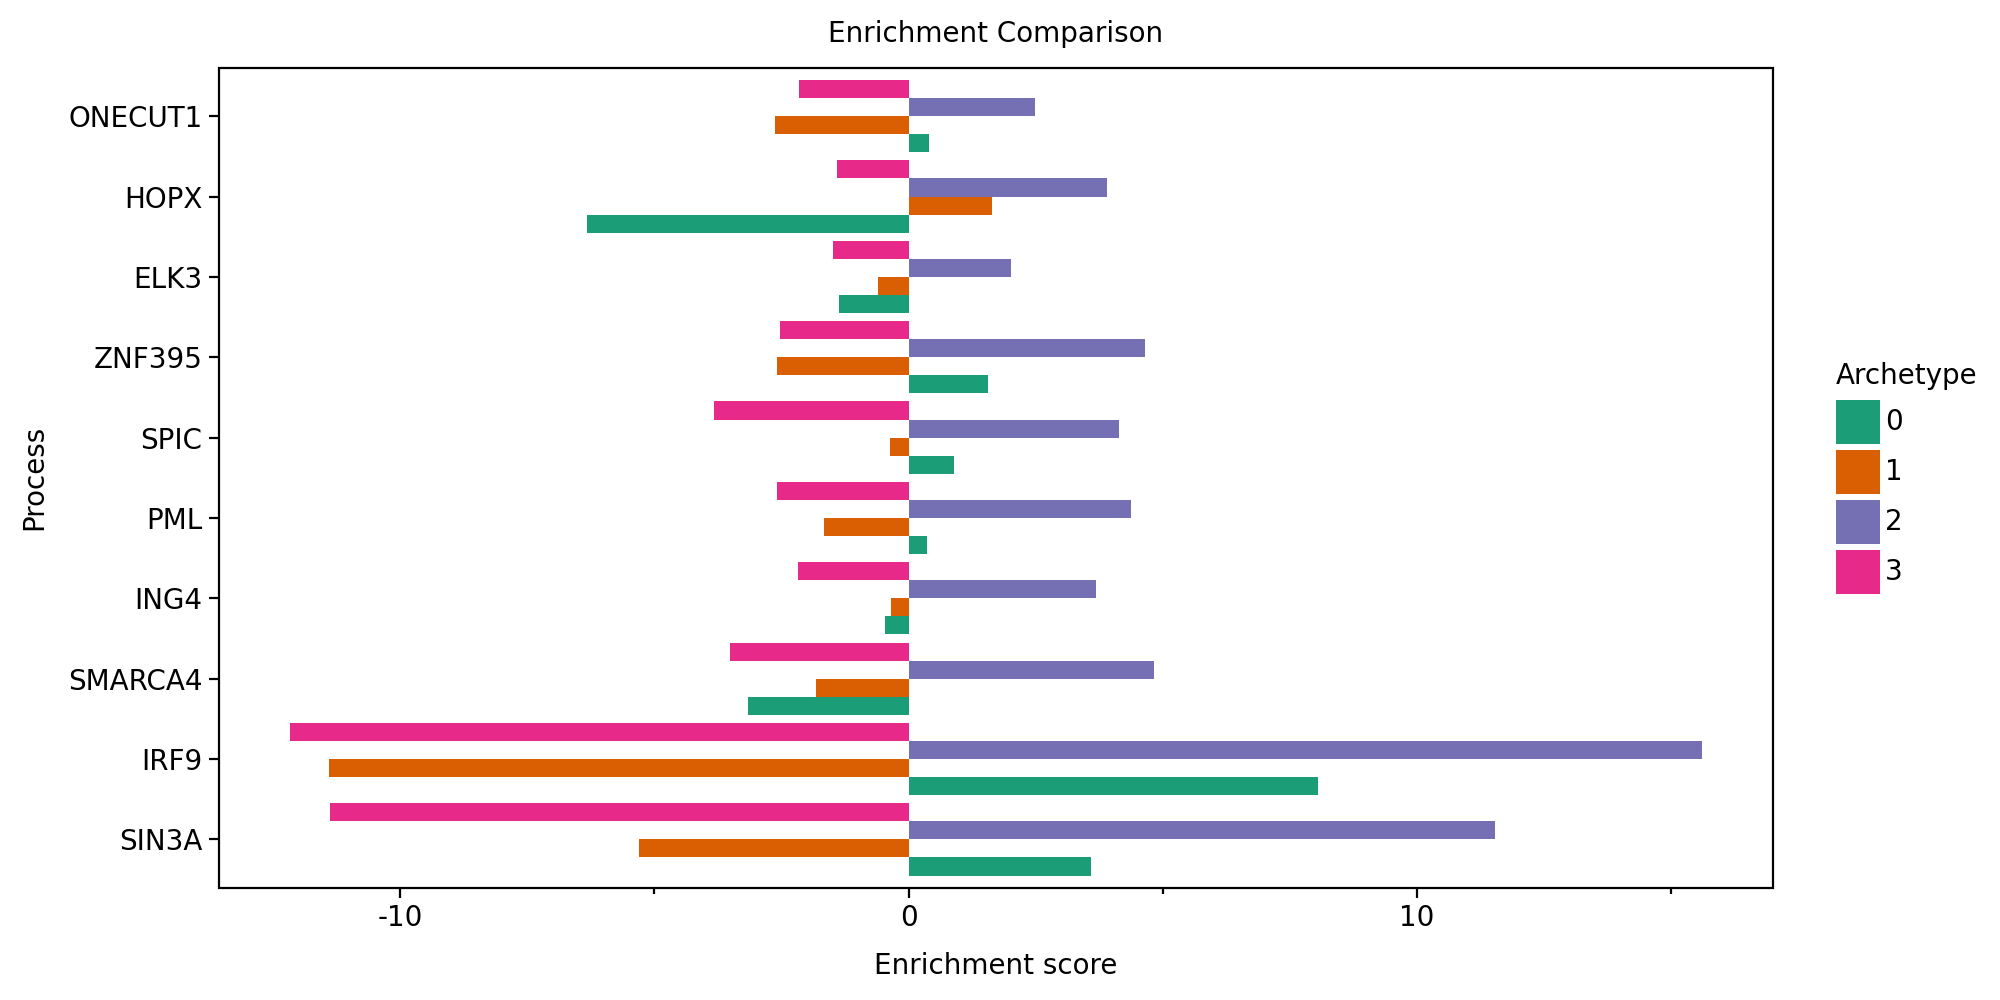

In [60]:
pt.barplot_enrichment_comparison(specific_processes_collectri[2])